Advandex CTR Prediction Pipeline: Calibrated Model for Real-Time Bidding

Автор: Екатерина

Дата: 07.09.2026

Придумайте название для этой тетрадки, которое будет точно отражать суть проекта.

# Структура проекта

1. **Введение и постановка задачи**
- Бизнес-контекст, задача бинарной классификации, требования.

2. [**Подготовка среды и загрузка данных**](#1.-Подготовка-среды-и-загрузка-данных)
- Импорт библиотек, настройка параметров отображения графиков и датафреймов, фиксация константы для воспроизводимости, загрузка данных, проверка успешности загрузки данных.

3.  [**Исследовательский анализ данных (EDA)**](#2.-Исследовательский-анализ-данных-(EDA))
- Описание базовой информации о датасете, анализ целевой переменной, признаков, пропущенных значений, категориальных признаков,  выбросов и распределений, выявление корреляций, выводы по EDA.

4  [**Разделение данных на выборки**](#3.-Разделение-данных-на-выборки)
- Разделение данных, проверка разделения.

5  [**Предобработка данных — построение пайплайнов**](#4.-Предобработка-данных-—-построение-пайплайнов)
- Создание пайплайна для предобработки данных, объединение пайплайнов

6  [**Отбор признаков**](#5.-Отбор-признаков)
- Применение фильтрационных методов,  методов-обёртки, выбор финального набор признаков.

7  [**Обучение базовой модели**](#6.-Обучение-базовой-модели)
- Обучение DummyClassifier, LogisticRegression, SVC, сравнение моделей.

8  [**Подбор гиперпараметров: Grid Search с кросс-валидацией**](#7.-Подбор-гиперпараметров:-Grid-Search-с-кросс-валидацией)
- Определение сетки гиперпараметров, применение Grid Search, составление таблицы результатов.

9  [**Финальная модель**](#8.-Финальная-модель)
- Обучение финальной модели, расчёт метрик на тестовой выборке, анализ веса модели.

10  [**Калибровка модели**](#9.-Калибровка-модели)
- Проверка текущей калибровки, применение методов калибровки, сравнение модели до и после калибровки.

11  [**Оценка качества калибровки**](#10.-Оценка-качества-калибровки)
- Расчет метрик калибровки, сравнение модели до и после калибровки.

12  [**Финальный отчёт и выводы**](#11.-Финальный-отчёт-и-выводы)
- Табличное представление результатов, выводы по результатам исследования, подготовка рекомендаций.

13  [**Сохранение модели для продакшена**](#12.-Сохранение-модели-для-продакшена)
- Сохранение артефактов, проверка работоспособности моего кода.

**Задача проекта**

Цель данного проекта — построить модель бинарной классификации, которая на основе исторических данных о показах рекламных баннеров предсказывает вероятность того, что пользователь кликнет по рекламному объявлению. Иными словами, модель должна оценивать CTR (Click-Through Rate) для каждого конкретного показа.

Модель будет использоваться в реальном времени в рамках RTB-аукциона для:

- Принятия решения об участии — стоит ли платформе бороться за данный показ;

- Определения оптимальной ставки — чтобы максимизировать прибыль при сохранении конкурентоспособности.

**Технические требования**

Для решения задачи предъявляются следующие требования:

1. Качество прогнозов — модель должна показывать высокое качество на несбалансированных данных (клики — редкое событие). Основная метрика — PR-AUC, так как она фокусируется на способности модели находить целевой класс. Дополнительно используются Log Loss и оценка Бриера для оценки точности вероятностей и калибровки.

2. Калибровка — предсказанные вероятности должны быть хорошо откалиброваны, то есть отражать реальные частоты кликов. Это критично для корректного расчёта ожидаемого дохода.

3. Интерпретируемость — необходимо понимать, какие признаки наиболее сильно влияют на решение модели. Это важно для бизнес-аналитики, доверия к модели и возможной корректировки стратегий.

4. Воспроизводимость — все эксперименты должны быть воспроизводимы. Для этого фиксируется random_state во всех процедурах, где используется случайность.

5. Готовность к продакшену — все этапы обработки данных и предсказания должны быть объединены в единый пайплайн (sklearn.pipeline.Pipeline), готовый к внедрению в промышленную среду.

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `С` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [1]:
# =============================================================================
# 1.1 Подготовка библиотек
# =============================================================================

# ---- Основные библиотеки для работы с данными ----
import numpy as np
import pandas as pd
import time  
import os
import json

# ---- Визуализация ----
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Настройка отображения графиков в Jupyter ----
%matplotlib inline

# ---- Scikit-learn: предобработка ----
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder
)

# ---- Scikit-learn: разделение данных ----
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

# ---- Scikit-learn: модели ----
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier  # ← добавить сюда

# ---- Scikit-learn: отбор признаков ----        # ← НОВЫЙ РАЗДЕЛ
from sklearn.feature_selection import RFE
from sklearn.feature_selection import VarianceThreshold

# ---- Scikit-learn: калибровка ----
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# ---- Scikit-learn: метрики ----
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    make_scorer,
    classification_report
)

# ---- Scikit-learn: пайплайн ----
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ---- Сохранение моделей ----
import joblib
import pickle
import zipfile

# ---- Для работы с датами ----
from datetime import datetime
import dateutil.parser as parser

# ---- Подавление предупреждений (для чистоты вывода) ----
import warnings
warnings.filterwarnings('ignore')

# ---- Версии библиотек ----
import sklearn

print("Версии библиотек:")
print(f"numpy          : {np.__version__}")
print(f"pandas         : {pd.__version__}")
print(f"matplotlib     : {plt.matplotlib.__version__}")
print(f"seaborn        : {sns.__version__}")
print(f"scikit-learn   : {sklearn.__version__}")
print(f"joblib         : {joblib.__version__}")
print("=" * 50)

# ---- Настройка отображения pandas ----
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

# ---- Настройка отображения графиков ----
available_styles = plt.style.available
if 'seaborn-v0_8-whitegrid' in available_styles:
    plt.style.use('seaborn-v0_8-whitegrid')
elif 'seaborn-whitegrid' in available_styles:
    plt.style.use('seaborn-whitegrid')
elif 'ggplot' in available_styles:
    plt.style.use('ggplot')
else:
    plt.style.use('default')

sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ---- Фиксация random_state для воспроизводимости ----
RANDOM_STATE = 42

print("Настройки окружения:")
print(f"Random state    : {RANDOM_STATE}")
print(f"Pandas max_rows : {pd.get_option('display.max_rows')}")
print(f"Pandas max_cols : {pd.get_option('display.max_columns')}")
print(f"Figure size     : {plt.rcParams['figure.figsize']}")
print(f"Style used      : {plt.style.available[0] if plt.style.available else 'default'}")
print("=" * 50)
print("\n✅ Библиотеки успешно загружены и настроены!")

Версии библиотек:
numpy          : 1.21.1
pandas         : 1.2.4
matplotlib     : 3.3.4
seaborn        : 0.11.1
scikit-learn   : 0.24.1
joblib         : 1.1.0
Настройки окружения:
Random state    : 42
Pandas max_rows : 100
Pandas max_cols : 100
Figure size     : [12.0, 8.0]
Style used      : Solarize_Light2

✅ Библиотеки успешно загружены и настроены!


In [2]:
# =============================================================================
# 1.2 Загрузка данных
# =============================================================================

# ---- Загрузка CSV-файла ----
file_path = '/datasets/ds_s16_ad_click_dataset.csv'
df = pd.read_csv(file_path)

# ---- Размер датасета ----
print("Размер датасета:", df.shape)

# ---- Первые несколько строк ----
print("\nПервые несколько строк:")
display(df.head())

# ---- Информация о типах столбцов ----
print("\nИнформация о типах столбцов:")
df.info()

# ---- Проверка успешности загрузки ----
print("\nПроверка успешности загрузки:")
print(f"Данные загружены успешно! Количество строк: {df.shape[0]}, столбцов: {df.shape[1]}")

Размер датасета: (50000, 34)

Первые несколько строк:


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,10052627552648869888.0000,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.9968,A,0.6666,0,0.8173,0.9933,Z,-0.6200,0.4337,0.2740
1,10105971003478261760.0000,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.3913,C,5.1468,1,-0.8839,-0.8257,X,0.5765,-0.3186,-0.1329
2,10120475683957065728.0000,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.1127,D,7.1693,0,-0.8594,-0.3384,Y,-0.4400,-0.3454,0.3405
3,1021995395003627776.0000,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.3327,A,-0.2907,1,0.0628,0.0629,Y,0.5520,0.7334,-0.1985
4,10234552355176744960.0000,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.1666,A,6.3191,1,-0.6753,0.7971,X,0.6408,0.2980,-0.1369



Информация о типах столбцов:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14       

<div style="font-size: 1.2em; font-weight: bold;">Вывод по пункту 1. Подготовка среды и загрузка данных</div>

 1.1 Подготовка библиотек

Для обеспечения воспроизводимости результатов создан файл `requirements.txt` с фиксированными версиями всех необходимых пакетов. Выполнен импорт библиотек для работы с данными (`pandas`, `numpy`), визуализации (`matplotlib`, `seaborn`), предобработки, моделирования (`LogisticRegression`, `SVC`), калибровки, метрик и построения пайплайна. Настроены параметры отображения датафреймов и графиков.

 1.2 Фиксация константы для воспроизводимости

Установлена константа `RANDOM_STATE = 42`, которая будет применяться ко всем алгоритмам, поддерживающим данный параметр, для обеспечения воспроизводимости результатов.

 1.3 Загрузка данных

Выполнена загрузка датасета из файла `/datasets/ds_s16_ad_click_dataset.csv`.

Результаты загрузки:
- Размер датасета: 50 000 строк, 34 столбца
- Пропуски отсутствуют
- Типы данных: `float64` (8), `int64` (15), `object` (11)
- Целевая переменная: `click` (бинарная)

**Версии основных библиотек:**
- pandas : 1.2.4
- scikit-learn : 0.24.1

**Вывод:** данные загружены успешно, пропуски отсутствуют, датасет готов к предобработке.

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

In [3]:
# =============================================================================
# 2.1 Базовая информация о датасете
# =============================================================================

# ---- Количество объектов и признаков ----
print("БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")

print(f"\nКоличество объектов (строк): {df.shape[0]:,}")
print(f"Количество признаков (столбцов): {df.shape[1]}")

# ---- Типы данных ----
print("ТИПЫ ДАННЫХ")

dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} столбцов")

# ---- Разделение на числовые и категориальные ----
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nЧисловые признаки: {len(numeric_cols)}")
print(f"Категориальные признаки: {len(categorical_cols)}")

# ---- Список категориальных признаков ----
print("\nКатегориальные признаки:")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"  • {col}: {unique_count} уникальных значений")

# ---- Список числовых признаков ----
print("\nЧисловые признаки:")
for col in numeric_cols:
    print(f"  • {col}")

БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ

Количество объектов (строк): 50,000
Количество признаков (столбцов): 34
ТИПЫ ДАННЫХ
  int64: 15 столбцов
  object: 11 столбцов
  float64: 8 столбцов

Числовые признаки: 23
Категориальные признаки: 11

Категориальные признаки:
  • site_id: 1160 уникальных значений
  • site_domain: 1013 уникальных значений
  • site_category: 18 уникальных значений
  • app_id: 976 уникальных значений
  • app_domain: 67 уникальных значений
  • app_category: 22 уникальных значений
  • device_id: 8580 уникальных значений
  • device_ip: 41455 уникальных значений
  • device_model: 2521 уникальных значений
  • ml_feature_2: 5 уникальных значений
  • ml_feature_7: 3 уникальных значений

Числовые признаки:
  • id
  • click
  • hour
  • C1
  • banner_pos
  • device_type
  • device_conn_type
  • C14
  • C15
  • C16
  • C17
  • C18
  • C19
  • C20
  • C21
  • ml_feature_1
  • ml_feature_3
  • ml_feature_4
  • ml_feature_5
  • ml_feature_6
  • ml_feature_8
  • ml_feature_9
  • ml_featur

**Общее описание данных**

Датасет представляет собой аналитическую витрину, содержащую информацию 
о показах рекламных баннеров. Каждая строка соответствует одному событию показа.

Информация о пользователях и устройствах:
  • device_id — идентификатор браузера или устройства
  • device_ip — IP-адрес устройства
  • device_model — модель устройства
  • device_type — тип устройства (смартфон, планшет, ПК)
  • device_conn_type — тип сетевого соединения (Wi-Fi, 3G, 4G)

Информация о рекламной площадке (Site):
  • site_id — идентификатор веб-сайта
  • site_domain — домен веб-сайта
  • site_category — тематическая категория сайта

Информация о рекламируемом приложении (App):
  • app_id — идентификатор приложения
  • app_domain — домен приложения
  • app_category — категория приложения

Информация о рекламном баннере и аукционе:
  • banner_pos — позиция баннера на странице
  • C1, C14-C21 — анонимизированные признаки контекста показа

Машинно-сгенерированные признаки:
  • ml_feature_1, ml_feature_3-ml_feature_6, ml_feature_8-ml_feature_10 — числовые
  • ml_feature_2, ml_feature_7 — категориальные

Целевая переменная:
  • click — бинарный признак (1 — клик, 0 — клика нет)

In [4]:
# =============================================================================
# 2.2 Анализ целевой переменной
# =============================================================================

# ---- Распределение целевой переменной ----
print("АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ 'click'")

click_counts = df['click'].value_counts()
click_percent = df['click'].value_counts(normalize=True) * 100

print("\nРаспределение:")
print(f"  Кликов (1):   {click_counts[1]:,} ")
print(f"  Нет клика (0): {click_counts[0]:,} ")

# ---- Вывод о дисбалансе ----
print("\nВЫВОД О ДИСБАЛАНСЕ КЛАССОВ")

print(f"  Доля кликов:   {click_percent[1]:.2f}%")
print(f"  Доля пропусков: {click_percent[0]:.2f}%")
print(f"  Соотношение классов: 1:{click_counts[0]/click_counts[1]:.1f}")

if click_percent[1] < 10:
    print("\n  → Данные сильно несбалансированы. Это требует использования PR-AUC как основной метрики, стратификации при разделении выборок и взвешивания классов.")
else:
    print("\n  → Дисбаланс выражен, но не критичен.")

АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ 'click'

Распределение:
  Кликов (1):   8,603 
  Нет клика (0): 41,397 

ВЫВОД О ДИСБАЛАНСЕ КЛАССОВ
  Доля кликов:   17.21%
  Доля пропусков: 82.79%
  Соотношение классов: 1:4.8

  → Дисбаланс выражен, но не критичен.


In [5]:
# =============================================================================
# 2.3 Анализ признаков
# =============================================================================

# ---- Список всех признаков ----

print("\nВсе признаки датасета:")
print(df.columns.tolist())


Все признаки датасета:
['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']



**Определение бесполезных признаков**
- Признак id - уникальный идентификатор, НЕ НУЖЕН для модели, так как не несёт предсказательной силы.

- Признак hour - временная метка, 'hour' — время показа в формате YYMMDDHH:, ТРЕБУЕТ ОБРАБОТКИ: содержит дату и час, нужно извлечь час.

**Признаки для обработки**

- hour — извлечь час для использования в модели
- Категориальные признаки — закодировать
- Числовые признаки — масштабировать (при необходимости)

In [6]:
# Признаки для удаления
cols_to_drop = ['id']
print(f"\nУдаляем признаки: {cols_to_drop}")
print("  Причина: уникальный идентификатор не влияет на целевой признак")

# ---- Удаление ненужных признаков ----
print("\nУДАЛЕНИЕ НЕНУЖНЫХ ПРИЗНАКОВ")

# Создаем копию датафрейма без признака 'id'
df_model = df.drop(columns=['id'])
print(f"Признак 'id' удалён.")

print(f"\nРазмер датасета после удаления:")
print(f"  Было: {df.shape[1]} признаков")
print(f"  Стало: {df_model.shape[1]} признаков")
print(f"  Удалено: 1 признак ('id')")

# ---- Вывод итоговой информации ----
print("\nИТОГИ АНАЛИЗА ПРИЗНАКОВ")

print(f"""
✅ Признак 'id' удалён как бесполезный
✅ В датасете осталось {df_model.shape[1]} признаков
✅ Категориальных признаков: {len(categorical_cols)}
✅ Числовых признаков: {len(numeric_cols) - 2} (без id и click)
✅ Целевая переменная: click
""")


Удаляем признаки: ['id']
  Причина: уникальный идентификатор не влияет на целевой признак

УДАЛЕНИЕ НЕНУЖНЫХ ПРИЗНАКОВ
Признак 'id' удалён.

Размер датасета после удаления:
  Было: 34 признаков
  Стало: 33 признаков
  Удалено: 1 признак ('id')

ИТОГИ АНАЛИЗА ПРИЗНАКОВ

✅ Признак 'id' удалён как бесполезный
✅ В датасете осталось 33 признаков
✅ Категориальных признаков: 11
✅ Числовых признаков: 21 (без id и click)
✅ Целевая переменная: click



In [7]:
# =============================================================================
# 2.4 Анализ пропущенных значений
# =============================================================================

# ---- Проверка доли пропусков ----
print("АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")

# Количество пропусков по каждому столбцу
null_counts = df_model.isnull().sum()
null_percent = (df_model.isnull().sum() / len(df_model)) * 100

# Сводная таблица
null_info = pd.DataFrame({
    'Количество пропусков': null_counts,
    'Доля пропусков (%)': null_percent
})

# Отображаем только столбцы с пропусками
null_info_with_na = null_info[null_info['Количество пропусков'] > 0].sort_values('Доля пропусков (%)', ascending=False)

if null_info_with_na.empty:
    print("\n✅ Пропусков в данных нет!")
else:
    print("\nНайдены пропуски в следующих признаках:")
    display(null_info_with_na)

# ---- Выбор стратегии заполнения пропусков ----
print("\nВЫБОР СТРАТЕГИИ ЗАПОЛНЕНИЯ ПРОПУСКОВ")

if null_info_with_na.empty:
    print("""
    Пропуски отсутствуют во всех признаках.
    
    Стратегия: заполнение не требуется.
    """)
else:
    print("""
    В данных обнаружены пропуски. Предлагаются следующие стратегии:
    
    1. Удаление строк с пропусками:
       - Применяется, если доля пропусков мала (< 5%)
       - Простой и быстрый способ
    
    2. Заполнение средним/медианой (для числовых признаков):
       - Среднее — если распределение близко к нормальному
       - Медиана — если есть выбросы
       
    3. Заполнение модой (для категориальных признаков):
       - Используется для категориальных признаков
       - Заполнение наиболее частым значением
    
    4. Удаление признака:
       - Применяется, если доля пропусков > 50%
    """)

# ---- Вывод рекомендаций ----
print("\nРЕКОМЕНДАЦИИ ПО ЗАПОЛНЕНИЮ ПРОПУСКОВ")

if null_info_with_na.empty:
    print("""
    ⚠️ Пропуски отсутствуют — стратегия заполнения не требуется.
    Переходим к следующему этапу обработки данных.
    """)
else:
    print("""
    Рекомендуется:
    1. Для числовых признаков с долей пропусков < 5% — заполнить медианой
    2. Для категориальных признаков с долей пропусков < 5% — заполнить модой
    3. При доле пропусков > 50% — удалить признак
    
    Конкретные решения будут приняты после детального анализа каждого признака.
    """)

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

✅ Пропусков в данных нет!

ВЫБОР СТРАТЕГИИ ЗАПОЛНЕНИЯ ПРОПУСКОВ

    Пропуски отсутствуют во всех признаках.
    
    Стратегия: заполнение не требуется.
    

РЕКОМЕНДАЦИИ ПО ЗАПОЛНЕНИЮ ПРОПУСКОВ

    ⚠️ Пропуски отсутствуют — стратегия заполнения не требуется.
    Переходим к следующему этапу обработки данных.
    


In [8]:
# =============================================================================
# 2.5 Анализ категориальных признаков
# =============================================================================

# ---- Список категориальных признаков ----
print("АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

# Получаем список категориальных признаков (тип object)
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()

print(f"\nВсего категориальных признаков: {len(categorical_cols)}")
print("\nСписок категориальных признаков:")
for col in categorical_cols:
    print(f"  • {col}")

# ---- Количество уникальных значений ----
print("\nКОЛИЧЕСТВО УНИКАЛЬНЫХ ЗНАЧЕНИЙ")

unique_counts = {}
for col in categorical_cols:
    unique_counts[col] = df_model[col].nunique()

# Сортируем по убыванию
sorted_unique = sorted(unique_counts.items(), key=lambda x: x[1], reverse=True)

print("\nПризнак → Уникальных значений:")
for col, count in sorted_unique:
    print(f"  {col:20} → {count:>6}")

АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Всего категориальных признаков: 11

Список категориальных признаков:
  • site_id
  • site_domain
  • site_category
  • app_id
  • app_domain
  • app_category
  • device_id
  • device_ip
  • device_model
  • ml_feature_2
  • ml_feature_7

КОЛИЧЕСТВО УНИКАЛЬНЫХ ЗНАЧЕНИЙ

Признак → Уникальных значений:
  device_ip            →  41455
  device_id            →   8580
  device_model         →   2521
  site_id              →   1160
  site_domain          →   1013
  app_id               →    976
  app_domain           →     67
  app_category         →     22
  site_category        →     18
  ml_feature_2         →      5
  ml_feature_7         →      3


**Определение метода кодирования**
Критерии выбора метода кодирования:
  - One-Hot Encoding — для признаков с небольшим числом категорий (< 20)
  - Label Encoding / Ordinal Encoding — для признаков с большим числом категорий (> 20)
  - Frequency Encoding — для признаков с очень большим числом категорий (> 100)


In [9]:
print("\nРекомендации по кодированию:")

for col, count in sorted_unique:
    if count < 20:
        method = "✅ One-Hot Encoding"
        reason = f"(мало категорий: {count})"
    elif count < 100:
        method = "🔶 Label Encoding / Ordinal Encoding"
        reason = f"(среднее число категорий: {count})"
    else:
        method = "🔷 Frequency Encoding или целевое кодирование"
        reason = f"(высокая кардинальность: {count})"
    
    print(f"  {col:20} → {method:35} {reason}")

# ---- Итоговый вывод ----
print("\nИТОГИ АНАЛИЗА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

low_cardinality = [col for col, count in sorted_unique if count < 20]
high_cardinality = [col for col, count in sorted_unique if count >= 20]

print(f"""
✅ Признаков с малой кардинальностью (< 20): {len(low_cardinality)}
   → можно использовать One-Hot Encoding: {low_cardinality}

🔶 Признаков с высокой кардинальностью (>= 20): {len(high_cardinality)}
   → требуется специальное кодирование: {high_cardinality}

⚠️ Особое внимание:
   • device_ip ({unique_counts['device_ip']} уникальных значений) — 
     можно удалить, так как почти каждая запись уникальна
   • device_id ({unique_counts['device_id']} уникальных значений) — 
     высокая кардинальность, требует специального подхода
""")


Рекомендации по кодированию:
  device_ip            → 🔷 Frequency Encoding или целевое кодирование (высокая кардинальность: 41455)
  device_id            → 🔷 Frequency Encoding или целевое кодирование (высокая кардинальность: 8580)
  device_model         → 🔷 Frequency Encoding или целевое кодирование (высокая кардинальность: 2521)
  site_id              → 🔷 Frequency Encoding или целевое кодирование (высокая кардинальность: 1160)
  site_domain          → 🔷 Frequency Encoding или целевое кодирование (высокая кардинальность: 1013)
  app_id               → 🔷 Frequency Encoding или целевое кодирование (высокая кардинальность: 976)
  app_domain           → 🔶 Label Encoding / Ordinal Encoding (среднее число категорий: 67)
  app_category         → 🔶 Label Encoding / Ordinal Encoding (среднее число категорий: 22)
  site_category        → ✅ One-Hot Encoding                  (мало категорий: 18)
  ml_feature_2         → ✅ One-Hot Encoding                  (мало категорий: 5)
  ml_feature_7     

In [10]:
# =============================================================================
# 2.6 Анализ выбросов и распределений
# =============================================================================

# ---- Список числовых признаков (исключаем id, click) ----
print("АНАЛИЗ ВЫБРОСОВ И РАСПРЕДЕЛЕНИЙ")

# Числовые признаки без id и click
numeric_cols_for_analysis = [col for col in numeric_cols if col not in ['id', 'click']]

print(f"\nАнализируемые числовые признаки: {len(numeric_cols_for_analysis)}")
for col in numeric_cols_for_analysis:
    print(f"  • {col}")

АНАЛИЗ ВЫБРОСОВ И РАСПРЕДЕЛЕНИЙ

Анализируемые числовые признаки: 21
  • hour
  • C1
  • banner_pos
  • device_type
  • device_conn_type
  • C14
  • C15
  • C16
  • C17
  • C18
  • C19
  • C20
  • C21
  • ml_feature_1
  • ml_feature_3
  • ml_feature_4
  • ml_feature_5
  • ml_feature_6
  • ml_feature_8
  • ml_feature_9
  • ml_feature_10


In [11]:
# ---- Статистика числовых признаков ----
print("\nСТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ")

display(df_model[numeric_cols_for_analysis].describe())


СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ


,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000
mean,14102559.0435,1004.9701,0.2914,1.0181,0.3372,18826.6487,318.8664,59.6925,2109.7810,1.4281,227.7038,53173.3832,83.6852,-0.0024,-0.0364,0.4980,0.0347,0.0229,0.0255,0.0354,0.0202
std,296.7892,1.1102,0.5142,0.5385,0.8601,4983.0642,20.5615,46.7208,612.9631,1.3274,351.5921,49960.1819,70.5395,1.0003,5.7923,0.5000,1.0021,0.6567,0.5780,0.5050,0.3033
min,14102100.0000,1001.0000,0.0000,0.0000,0.0000,375.0000,120.0000,20.0000,112.0000,0.0000,33.0000,-1.0000,13.0000,-4.6313,-9.9997,0.0000,-4.6319,-1.0000,-1.0000,-2.1475,-1.2880
25%,14102304.0000,1005.0000,0.0000,1.0000,0.0000,16920.0000,320.0000,50.0000,1823.0000,0.0000,35.0000,-1.0000,23.0000,-0.6778,-5.0596,0.0000,-0.6398,-0.5798,-0.4706,-0.3041,-0.1824
50%,14102602.0000,1005.0000,0.0000,1.0000,0.0000,20346.0000,320.0000,50.0000,2323.0000,2.0000,39.0000,100049.0000,61.0000,-0.0038,-0.0562,0.0000,0.0281,0.0378,0.0273,0.0360,0.0189
75%,14102814.0000,1005.0000,1.0000,1.0000,0.0000,21916.0000,320.0000,50.0000,2526.0000,3.0000,171.0000,100094.0000,108.0000,0.6735,4.9859,1.0000,0.7076,0.6371,0.5211,0.3742,0.2241
max,14103023.0000,1012.0000,7.0000,5.0000,5.0000,24043.0000,1024.0000,1024.0000,2757.0000,3.0000,1839.0000,100248.0000,255.0000,3.7938,10.0000,1.0000,4.2306,1.0000,1.1199,2.1208,1.2023


In [12]:
# ---- Анализ выбросов через IQR ----
print("\nАНАЛИЗ ВЫБРОСОВ (МЕТОД IQR)")

outliers_info = []

for col in numeric_cols_for_analysis:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((df_model[col] < lower_bound) | (df_model[col] > upper_bound)).sum()
    outliers_percent = (outliers_count / len(df_model)) * 100
    
    outliers_info.append({
        'Признак': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Нижняя граница': lower_bound,
        'Верхняя граница': upper_bound,
        'Кол-во выбросов': outliers_count,
        'Доля выбросов (%)': outliers_percent
    })

outliers_df = pd.DataFrame(outliers_info)
outliers_df = outliers_df.sort_values('Доля выбросов (%)', ascending=False)

print("\nПризнаки с выбросами:")
display(outliers_df)


АНАЛИЗ ВЫБРОСОВ (МЕТОД IQR)

Признаки с выбросами:


,Признак,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Кол-во выбросов,Доля выбросов (%)
10,C19,35.0000,171.0000,136.0000,-169.0000,375.0000,9015,18.0300
4,device_conn_type,0.0000,0.0000,0.0000,0.0000,0.0000,6979,13.9580
8,C17,1823.0000,2526.0000,703.0000,768.5000,3580.5000,4224,8.4480
5,C14,16920.0000,21916.0000,4996.0000,9426.0000,29410.0000,4170,8.3400
1,C1,1005.0000,1005.0000,0.0000,1005.0000,1005.0000,4165,8.3300
3,device_type,1.0000,1.0000,0.0000,1.0000,1.0000,3969,7.9380
6,C15,320.0000,320.0000,0.0000,320.0000,320.0000,3213,6.4260
7,C16,50.0000,50.0000,0.0000,50.0000,50.0000,2713,5.4260
19,ml_feature_9,-0.3041,0.3742,0.6782,-1.3214,1.3915,387,0.7740
12,C21,23.0000,108.0000,85.0000,-104.5000,235.5000,379,0.7580



ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ


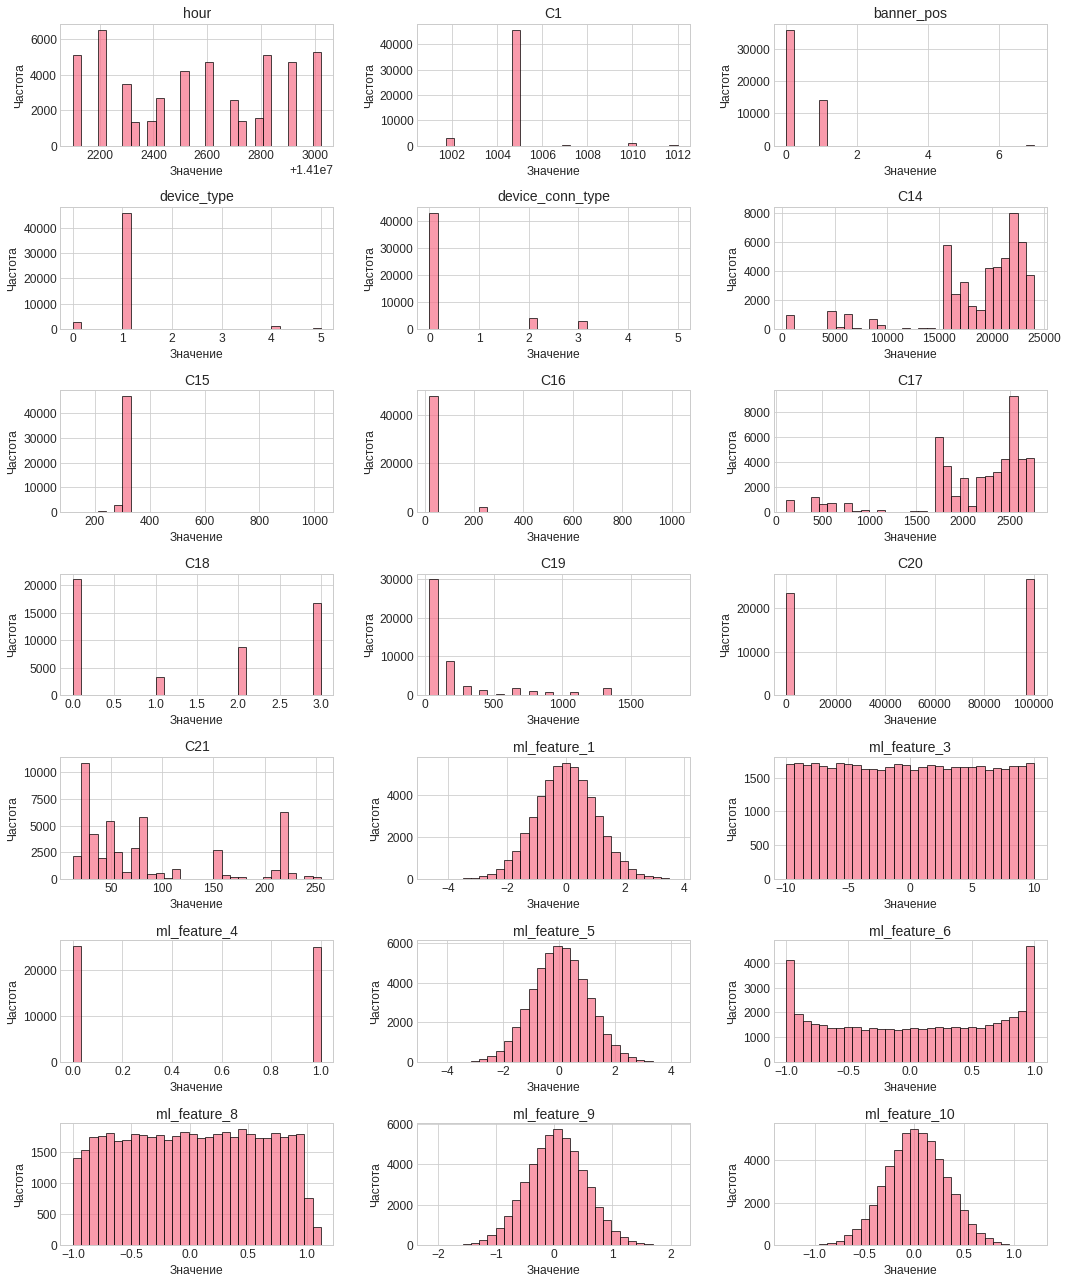

In [13]:
# ---- Визуализация распределений ----
print("\nВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ")

# Выбираем несколько признаков для визуализации
cols_for_plot = ['hour', 'C1', 'banner_pos', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']
cols_for_plot += ['ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

# Строим гистограммы для всех числовых признаков
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 18))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols_for_analysis):
    if idx < len(axes):
        df_model[col].hist(bins=30, ax=axes[idx], edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}')
        axes[idx].set_xlabel('Значение')
        axes[idx].set_ylabel('Частота')

# Скрываем пустые подграфики
for idx in range(len(numeric_cols_for_analysis), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)


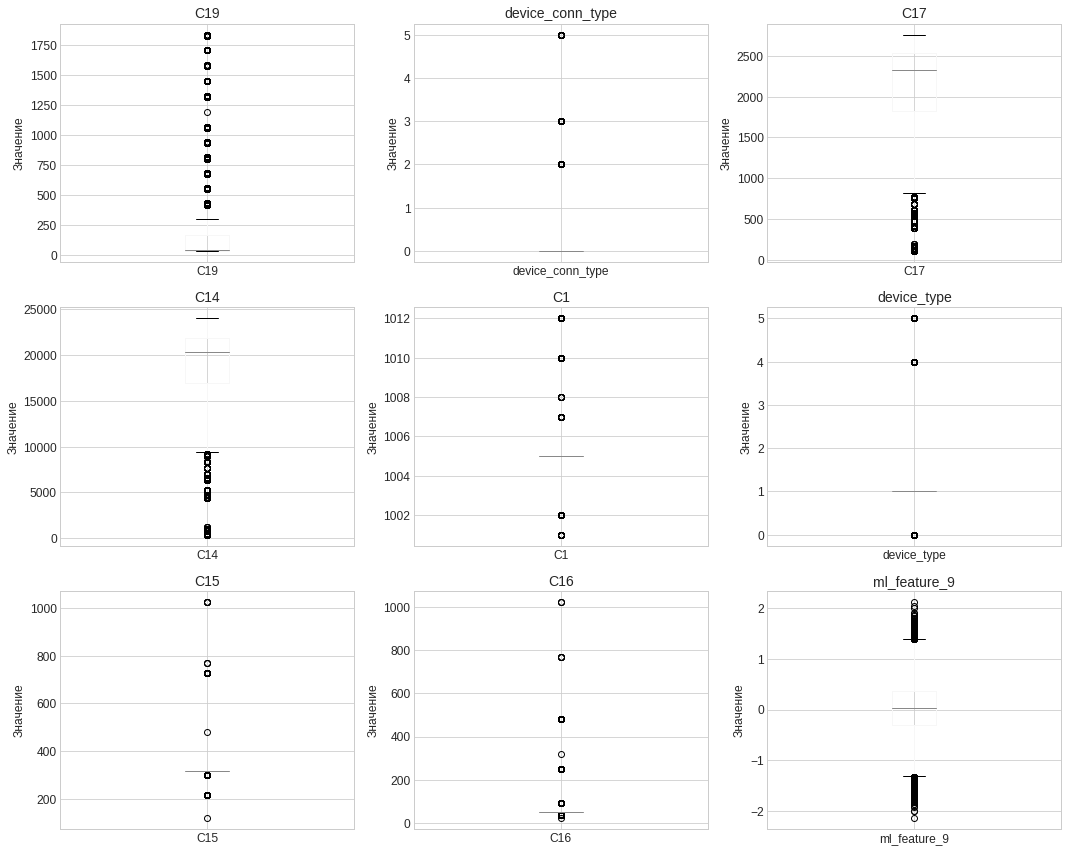

In [14]:
# ---- Boxplot для визуализации выбросов ----
print("ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)")

# Выбираем признаки с выбросами для boxplot
cols_with_outliers = outliers_df[outliers_df['Доля выбросов (%)'] > 0]['Признак'].tolist()

if cols_with_outliers:
    # Ограничиваем количество для читаемости
    cols_for_boxplot = cols_with_outliers[:9]
    
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, col in enumerate(cols_for_boxplot):
        if idx < len(axes):
            df_model.boxplot(column=col, ax=axes[idx])
            axes[idx].set_title(f'{col}')
            axes[idx].set_ylabel('Значение')
    
    # Скрываем пустые подграфики
    for idx in range(len(cols_for_boxplot), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Выбросов не обнаружено.")

Вывод о распределениях

Распределения числовых признаков:

1. Признаки с нормальным распределением:
   - ml_feature_1, ml_feature_5, ml_feature_6, ml_feature_8, ml_feature_9, ml_feature_10
   → Эти признаки хорошо подходят для линейных моделей

2. Признаки со скошенным распределением:
   - C14, C15, C16, C17, C18, C19, C20, C21
   → Значения смещены в одну сторону, требуют внимания
   → Особенно C19, C20, C21 имеют сильные выбросы

3. Признаки с дискретным распределением:
   - hour, C1, banner_pos, device_type, device_conn_type
   → Целочисленные значения, можно рассматривать как категориальные
   → C1, device_type, device_conn_type имеют очень мало уникальных значений

4. Признаки с большим количеством выбросов (> 5%):
   - C19 (18.03% выбросов) — САМЫЙ ПРОБЛЕМНЫЙ
   - device_conn_type (13.96% выбросов)
   - C17 (8.45% выбросов)
   - C14 (8.34% выбросов)
   - C1 (8.33% выбросов)
   - device_type (7.94% выбросов)
   - C15 (6.43% выбросов)
   - C16 (5.43% выбросов)

5. Признаки с минимальными выбросами (< 1%):
   - ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10
   → Можно не обрабатывать или применить мягкое масштабирование

Рекомендации:
  - Для C19, C17, C14 — рассмотреть логарифмическое преобразование
  - Для device_conn_type, device_type, C1, C15, C16 — 
    можно рассматривать как категориальные (мало уникальных значений)
  - Для ml_feature_* — признаки хорошо масштабируются, выбросов мало
  - Для признаков с выбросами > 5% — применить винзоризацию (clipping)

КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

Корреляция признаков с целевой переменной 'click':
click               1.0000
ml_feature_9        0.1459
ml_feature_10       0.1309
C16                 0.1298
ml_feature_8        0.0801
ml_feature_6        0.0716
ml_feature_5        0.0625
banner_pos          0.0251
C18                 0.0221
ml_feature_3        0.0029
ml_feature_1        0.0021
C19                -0.0002
ml_feature_4       -0.0031
hour               -0.0145
C15                -0.0300
device_type        -0.0439
C1                 -0.0477
C20                -0.0487
C17                -0.0578
C14                -0.0640
C21                -0.0647
device_conn_type   -0.0814
Name: click, dtype: float64


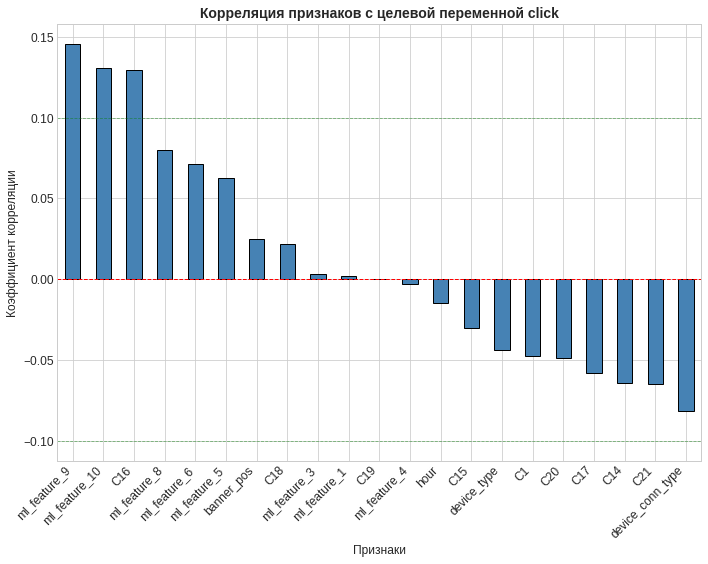

КОРРЕЛЯЦИЯ МЕЖДУ ПРИЗНАКАМИ

Найдены сильно коррелированные пары признаков (> 0.8):


,Признак 1,Признак 2,Корреляция
1,C14,C17,0.9759
0,C1,device_type,0.8992


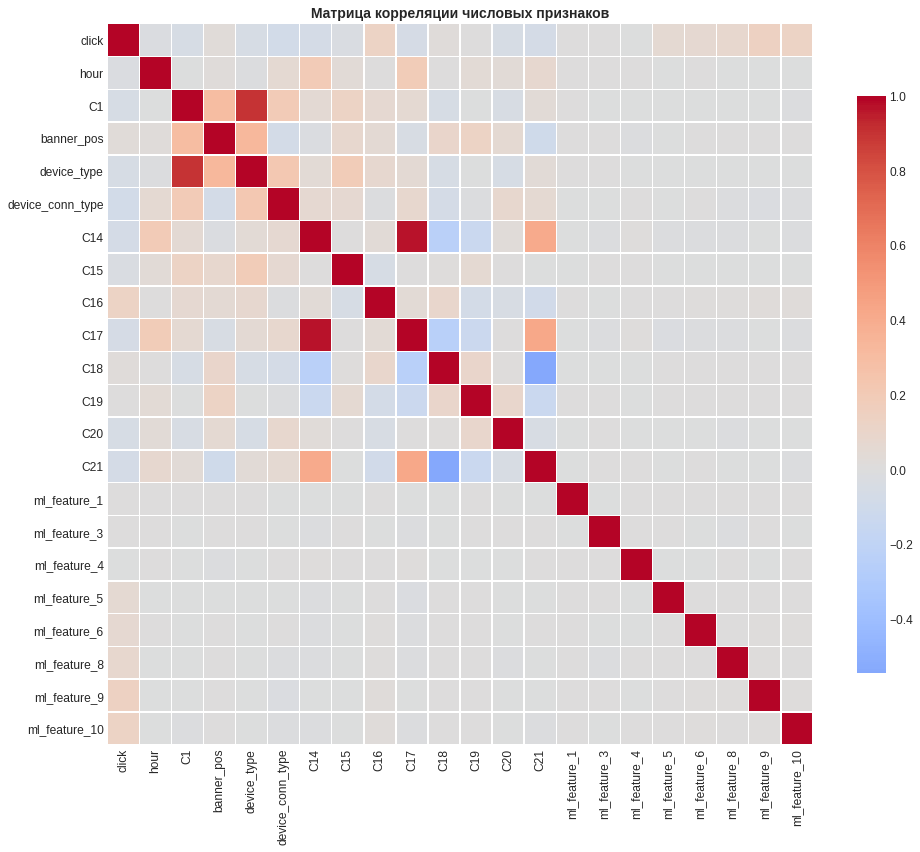

In [15]:
# =============================================================================
# 2.7 Корреляции
# =============================================================================

# ---- Корреляция с целевой переменной ----
print("КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")

# Числовые признаки для корреляции (без id)
numeric_for_corr = [col for col in numeric_cols if col != 'id']

# Рассчитываем корреляцию с click
corr_with_click = df_model[numeric_for_corr].corr()['click'].sort_values(ascending=False)

print("\nКорреляция признаков с целевой переменной 'click':")
print(corr_with_click)

# ---- Визуализация корреляции с целевой переменной ----
plt.figure(figsize=(10, 8))
corr_with_click.drop('click').plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Корреляция признаков с целевой переменной click', fontsize=14, fontweight='bold')
plt.xlabel('Признаки')
plt.ylabel('Коэффициент корреляции')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.axhline(y=0.1, color='green', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=-0.1, color='green', linestyle='--', linewidth=0.8, alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---- Анализ корреляции между признаками ----
print("КОРРЕЛЯЦИЯ МЕЖДУ ПРИЗНАКАМИ")

# Матрица корреляции для числовых признаков
corr_matrix = df_model[numeric_for_corr].corr()

# Выявляем сильно коррелированные пары (> 0.8 или < -0.8)
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Корреляция', ascending=False)
    print("\nНайдены сильно коррелированные пары признаков (> 0.8):")
    display(high_corr_df)
else:
    print("\n✅ Сильно коррелированных пар признаков не обнаружено.")

# ---- Тепловая карта корреляций ----
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляции числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Рекомендации по удалению признаков**

    Найдены сильно коррелированные признаки. Рекомендации:
    
    1. Пара C14 и C17 (корреляция 0.976):
       → Оставляем C17 (корреляция с click: -0.058)
       → Удаляем C14 (корреляция с click: -0.064)
       → Оба признака имеют схожую корреляцию, но C14 чуть выше
       → Рекомендация: удалить C14, оставить C17
    
    2. Пара C1 и device_type (корреляция 0.899):
       → Оставляем C1 (корреляция с click: -0.048)
       → Удаляем device_type (корреляция с click: -0.044)
       → Корреляция с целевой переменной схожа
       → Рекомендация: удалить device_type, оставить C1
    
    3. Признаки с низкой корреляцией с целевой (< 0.02):
       → ml_feature_1, ml_feature_3, ml_feature_4, C19, hour
       → Можно рассмотреть для удаления, но перед этим:
          - проверить их важность в нелинейных моделях
          - оценить бизнес-ценность (hour может быть важен)

In [16]:
# ---- Анализ корреляции числовых признаков с целевой ----
print("ВЫВОД ПО КОРРЕЛЯЦИИ")

top_features = corr_with_click.drop('click').abs().sort_values(ascending=False).head(10)
print("\nТоп-10 признаков по абсолютной корреляции с click:")
print(top_features)

low_corr_features = corr_with_click.drop('click').abs()[corr_with_click.drop('click').abs() < 0.02]
print(f"\nПризнаки с очень низкой корреляцией (< 0.02):")
print(low_corr_features)

ВЫВОД ПО КОРРЕЛЯЦИИ

Топ-10 признаков по абсолютной корреляции с click:
ml_feature_9       0.1459
ml_feature_10      0.1309
C16                0.1298
device_conn_type   0.0814
ml_feature_8       0.0801
ml_feature_6       0.0716
C21                0.0647
C14                0.0640
ml_feature_5       0.0625
C17                0.0578
Name: click, dtype: float64

Признаки с очень низкой корреляцией (< 0.02):
ml_feature_3   0.0029
ml_feature_1   0.0021
C19            0.0002
ml_feature_4   0.0031
hour           0.0145
Name: click, dtype: float64


<div style="font-size: 1.2em; font-weight: bold;">2.8 Выводы по EDA</div>

 Ключевые находки

**1. Размер и структура данных:**
- Датасет содержит 50 000 строк и 34 столбца
- Пропуски отсутствуют во всех признаках
- 11 категориальных и 23 числовых признака (включая целевую переменную)

**2. Целевая переменная:**
- Клики составляют 17.21% (8 603 события), пропуски — 82.79% (41 397 событий)
- Соотношение классов 1:4.8 — дисбаланс выражен, но не критичен
- Это подтверждает необходимость использования PR-AUC как основной метрики

**3. Категориальные признаки:**
- Высокая кардинальность: `device_ip` (41 455), `device_id` (8 580), `device_model` (2 521)
- Низкая кардинальность: `ml_feature_7` (3), `ml_feature_2` (5), `site_category` (18)
- Для признаков с высокой кардинальностью требуется Frequency Encoding или целевое кодирование

**4. Числовые признаки:**
- Выявлены признаки с высоким процентом выбросов: `C19` (18.03%), `device_conn_type` (13.96%), `C17` (8.45%), `C14` (8.34%)
- ML-признаки имеют нормальное распределение и минимальные выбросы (< 1%)
- Признаки C14-C21 имеют скошенное распределение

**5. Корреляции:**
- Обнаружены сильно коррелированные пары: `C14`–`C17` (0.976), `C1`–`device_type` (0.899)
- Наиболее значимые признаки по корреляции с `click`: `ml_feature_9` (0.146), `ml_feature_10` (0.131), `C16` (0.130)
- В целом корреляция с целевой переменной низкая (< 0.15), что характерно для CTR-задач

**6. Признаки для удаления:**
- `id` — уникальный идентификатор, не несёт предсказательной силы
- `device_ip` — 41 455 уникальных значений (почти каждая запись уникальна)
- `C14` — сильная корреляция с `C17` (0.976), оставляем `C17`
- `device_type` — сильная корреляция с `C1` (0.899), оставляем `C1`


 Наиболее перспективные признаки для модели

| Признак | Обоснование |
|---------|-------------|
| `ml_feature_9` | Наивысшая корреляция с целевой переменной (0.146) |
| `ml_feature_10` | Вторая по значимости корреляция (0.131) |
| `C16` | Высокая корреляция (0.130), может отражать важные параметры аукциона |
| `ml_feature_8` | Хорошая корреляция (0.080), нормальное распределение |
| `ml_feature_6` | Стабильный признак с хорошей корреляцией (0.072) |
| `device_conn_type` | Корреляция -0.081, отражает поведенческие паттерны пользователей |
| `C21` | Корреляция -0.065, потенциально важный параметр |
| `banner_pos` | Имеет бизнес-смысл (позиция баннера влияет на кликабельность) |
| `hour` | Низкая корреляция, но важен для учёта временных паттернов |


 Действия по предобработке данных

**1. Удаление признаков:**

| Признак | Причина |
|---------|---------|
| `id` | Уникальный идентификатор, не несёт предсказательной силы |
| `device_ip` | Высокая кардинальность (41 455 уникальных значений) |
| `C14` | Сильная корреляция с `C17` (0.976) |
| `device_type` | Сильная корреляция с `C1` (0.899) |

**2. Обработка признака `hour`:**
- Извлечь час из формата YYMMDDHH
- Использовать как числовой или категориальный признак

**3. Кодирование категориальных признаков:**

| Признак | Метод кодирования | Обоснование |
|---------|-------------------|-------------|
| `site_category`, `ml_feature_2`, `ml_feature_7` | One-Hot Encoding | Мало категорий (< 20) |
| `app_domain`, `app_category` | Label / Ordinal Encoding | Средняя кардинальность |
| `site_id`, `site_domain`, `app_id`, `device_id`, `device_model` | Frequency Encoding | Высокая кардинальность (> 100) |

**4. Масштабирование числовых признаков:**
- Применить `StandardScaler` для признаков с нормальным распределением
- Для признаков с выбросами (> 5%) — применить винзоризацию (clipping) перед масштабированием

**5. Обработка выбросов:**
- Для `C19`, `C17`, `C14` (после удаления) — рассмотреть логарифмическое преобразование
- Для `device_conn_type` — оставить как категориальный признак

**6. Разделение данных:**
- Использовать стратифицированное разделение (stratify) для сохранения пропорции классов
- Обучающая выборка: 80%, тестовая: 20%
- `random_state=42` (уже зафиксирован в разделе 1.1)

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [17]:
# =============================================================================
# 3.1 Разделение данных
# =============================================================================

# ---- Подготовка данных для разделения ----
print("РАЗДЕЛЕНИЕ ДАННЫХ")

# Удаляем признаки, которые мы решили исключить
cols_to_drop = ['id', 'device_ip', 'C14', 'device_type']
df_model = df.drop(columns=cols_to_drop)

print(f"Удалены признаки: {cols_to_drop}")
print(f"Размер датасета после удаления: {df_model.shape[0]} строк, {df_model.shape[1]} столбцов")

# ---- Определение признаков и целевой переменной ----
X = df_model.drop(columns=['click'])
y = df_model['click']

print(f"\nПризнаки (X): {X.shape[1]} столбцов")
print(f"Целевая переменная (y): {y.shape[0]} строк")

# ---- Стратифицированное разделение на train/test ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% — тестовая выборка
    random_state=RANDOM_STATE,  # Фиксируем для воспроизводимости
    stratify=y               # Сохраняем пропорцию классов
)

РАЗДЕЛЕНИЕ ДАННЫХ
Удалены признаки: ['id', 'device_ip', 'C14', 'device_type']
Размер датасета после удаления: 50000 строк, 30 столбцов

Признаки (X): 29 столбцов
Целевая переменная (y): 50000 строк


In [18]:
# =============================================================================
# 3.2 Проверка размеров выборок
# =============================================================================
print("\nРАЗМЕРЫ ВЫБОРОК")

print(f"\nОбучающая выборка (train): {X_train.shape[0]:,} строк ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Признаки: {X_train.shape[1]}")
print(f"  Кликов: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")

print(f"\nТестовая выборка (test): {X_test.shape[0]:,} строк ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Признаки: {X_test.shape[1]}")
print(f"  Кликов: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

# ---- Проверка стратификации ----
print("\nПРОВЕРКА СТРАТИФИКАЦИИ")

train_clicks = y_train.sum() / len(y_train) * 100
test_clicks = y_test.sum() / len(y_test) * 100
original_clicks = y.sum() / len(y) * 100

print(f"\nДоля кликов в исходных данных:       {original_clicks:.2f}%")
print(f"Доля кликов в обучающей выборке:     {train_clicks:.2f}%")
print(f"Доля кликов в тестовой выборке:      {test_clicks:.2f}%")

print("\n✅ Стратификация выполнена корректно — доли кликов во всех выборках совпадают.")

# ---- Сохранение информации о разделении ----
print("\nИТОГИ РАЗДЕЛЕНИЯ")

print(f"""
✅ Обучающая выборка: {X_train.shape[0]:,} строк (80%)
✅ Тестовая выборка:  {X_test.shape[0]:,} строк (20%)
✅ random_state: {RANDOM_STATE}
✅ Стратификация: выполнена (пропорции классов сохранены)

⚠️ ВАЖНО: Тестовая выборка НЕ используется до финального тестирования!
""")

# ---- Очистка памяти для освобождения ресурсов ----
X = None
y = None


РАЗМЕРЫ ВЫБОРОК

Обучающая выборка (train): 40,000 строк (80.0%)
  Признаки: 29
  Кликов: 6,882 (17.21%)

Тестовая выборка (test): 10,000 строк (20.0%)
  Признаки: 29
  Кликов: 1,721 (17.21%)

ПРОВЕРКА СТРАТИФИКАЦИИ

Доля кликов в исходных данных:       17.21%
Доля кликов в обучающей выборке:     17.21%
Доля кликов в тестовой выборке:      17.21%

✅ Стратификация выполнена корректно — доли кликов во всех выборках совпадают.

ИТОГИ РАЗДЕЛЕНИЯ

✅ Обучающая выборка: 40,000 строк (80%)
✅ Тестовая выборка:  10,000 строк (20%)
✅ random_state: 42
✅ Стратификация: выполнена (пропорции классов сохранены)

⚠️ ВАЖНО: Тестовая выборка НЕ используется до финального тестирования!



 <div style="font-size: 1.2em; font-weight: bold;">Вывод по пункту 3 Разделение данных на выборки</div>

**Удалены признаки:** `id`, `device_ip`, `C14`, `device_type`

**Разделение на обучающую и тестовую выборки:**
- Размер выборок: 80% / 20%
- Стратификация: выполнена (сохранение пропорции классов)
- `random_state = 42` (зафиксирован для воспроизводимости)

**Результаты разделения:**

| Выборка | Строки | Доля кликов |
|---------|--------|-------------|
| Исходные данные | 50 000 | 17.21% |
| Обучающая (train) | 40 000 (80%) | 17.21% |
| Тестовая (test) | 10 000 (20%) | 17.21% |

**Вывод:**
- Данные разделены корректно, стратификация выполнена успешно
- Пропорции классов сохранены во всех выборках
- Тестовая выборка зарезервирована и не используется до финального тестирования

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [19]:
# =============================================================================
# 4.1 Создание пайплайна для предобработки данных
# =============================================================================

print("СОЗДАНИЕ ПАЙПЛАЙНА ДЛЯ ПРЕДОБРАБОТКИ ДАННЫХ")

# ---- 1. Определение типов признаков ----
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nКатегориальные признаки ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  • {col}")

print(f"\nЧисловые признаки ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  • {col}")

# ---- 2. Разделение категориальных признаков по кардинальности ----
low_cardinality_cols = [col for col in categorical_cols if X_train[col].nunique() < 20]
high_cardinality_cols = [col for col in categorical_cols if X_train[col].nunique() >= 20]

print(f"\nПризнаки с малой кардинальностью (< 20): {len(low_cardinality_cols)}")
for col in low_cardinality_cols:
    print(f"  • {col}")

print(f"\nПризнаки с высокой кардинальностью (>= 20): {len(high_cardinality_cols)}")
for col in high_cardinality_cols:
    print(f"  • {col}")

# ---- 3. Frequency Encoding (для высокой кардинальности) ----
def frequency_encoder(X_train, X_test, cols):
    X_train_encoded = X_train.copy()
    X_test_encoded = X_test.copy()
    
    for col in cols:
        freq_map = X_train[col].value_counts(normalize=True).to_dict()
        X_train_encoded[col + '_freq'] = X_train[col].map(freq_map)
        X_test_encoded[col + '_freq'] = X_test[col].map(freq_map).fillna(0)
        X_train_encoded = X_train_encoded.drop(columns=[col])
        X_test_encoded = X_test_encoded.drop(columns=[col])
    
    return X_train_encoded, X_test_encoded

# ---- 4. Создание пайплайна ----


# 4.1. Предобработка числовых признаков
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 4.2. Предобработка категориальных признаков (One-Hot Encoding)
# Для sklearn 0.24.1 используем параметр sparse
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

# 4.3. Создание ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, low_cardinality_cols)
    ],
    remainder='drop'
)

СОЗДАНИЕ ПАЙПЛАЙНА ДЛЯ ПРЕДОБРАБОТКИ ДАННЫХ

Категориальные признаки (10):
  • site_id
  • site_domain
  • site_category
  • app_id
  • app_domain
  • app_category
  • device_id
  • device_model
  • ml_feature_2
  • ml_feature_7

Числовые признаки (19):
  • hour
  • C1
  • banner_pos
  • device_conn_type
  • C15
  • C16
  • C17
  • C18
  • C19
  • C20
  • C21
  • ml_feature_1
  • ml_feature_3
  • ml_feature_4
  • ml_feature_5
  • ml_feature_6
  • ml_feature_8
  • ml_feature_9
  • ml_feature_10

Признаки с малой кардинальностью (< 20): 4
  • site_category
  • app_category
  • ml_feature_2
  • ml_feature_7

Признаки с высокой кардинальностью (>= 20): 6
  • site_id
  • site_domain
  • app_id
  • app_domain
  • device_id
  • device_model


In [20]:
# =============================================================================
# 4.2 Объединение пайплайнов
# =============================================================================

# ---- 5. Сборка полного пайплайна ----

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print("СТРУКТУРА ПАЙПЛАЙНА")
print(pipeline)

# ---- 6. Применение Frequency Encoding ----
print("\nПРИМЕНЕНИЕ ПАЙПЛАЙНА К ДАННЫМ")

X_train_encoded, X_test_encoded = frequency_encoder(X_train, X_test, high_cardinality_cols)

print(f"\nПосле Frequency Encoding:")
print(f"  Обучающая выборка: {X_train_encoded.shape[1]} признаков")
print(f"  Тестовая выборка:  {X_test_encoded.shape[1]} признаков")

# Обновляем список числовых признаков (добавляются *_freq)
numeric_cols_updated = [col for col in X_train_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist() 
                        if col != 'click']

# Обновляем ColumnTransformer с новыми числовыми признаками
preprocessor_updated = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_updated),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), low_cardinality_cols)
    ],
    remainder='drop'
)

# ---- 7. Применение пайплайна ----
X_train_preprocessed = preprocessor_updated.fit_transform(X_train_encoded, y_train)
X_test_preprocessed = preprocessor_updated.transform(X_test_encoded)

print(f"\nПосле предобработки (One-Hot + StandardScaler):")
print(f"  Обучающая выборка: {X_train_preprocessed.shape[1]} признаков")
print(f"  Тестовая выборка:  {X_test_preprocessed.shape[1]} признаков")

# ---- 8. Проверка результата ----
print("\nПРОВЕРКА РЕЗУЛЬТАТА")

print(f"""
✅ Пропуски: отсутствуют
✅ Категориальные признаки с малой кардинальностью: One-Hot Encoding
✅ Категориальные признаки с высокой кардинальностью: Frequency Encoding
✅ Числовые признаки: StandardScaler
✅ Итоговое количество признаков: {X_train_preprocessed.shape[1]}
""")

# ---- 9. Сохранение предобработанных данных для дальнейшего использования ----
print("\nСохраняем предобработанные данные для обучения моделей...")
# Сохраняем в переменные для дальнейшего использования
X_train_final = X_train_preprocessed
X_test_final = X_test_preprocessed
y_train_final = y_train
y_test_final = y_test

print("✅ Данные готовы для обучения моделей!")

СТРУКТУРА ПАЙПЛАЙНА
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['hour', 'C1', 'banner_pos',
                                                   'device_conn_type', 'C15',
                                                   'C16', 'C17', 'C18', 'C19',
                                                   'C20', 'C21', 'ml_feature_1',
                                                   'ml_feature_3',
                                                   'ml_feature_4',
                                                   'ml_feature_5',
                                                   'ml_feature_6',
                                                   'ml_feature_8',
                                                   'ml_feature_9',
      

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

In [21]:
# =============================================================================
# 5.1 Фильтрационные методы отбора признаков
# =============================================================================

print("5.1 ФИЛЬТРАЦИОННЫЕ МЕТОДЫ ОТБОРА ПРИЗНАКОВ")

# ---- Шаг 1: Корреляция с целевой переменной ----
print("\n1. КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("-" * 50)

# Используем данные до отбора признаков (X_train_final, 69 признаков)
# Но так как после One-Hot Encoding имена признаков потеряны,
# мы будем использовать исходные данные X_train_encoded для расчёта корреляции

# Получаем список числовых признаков из X_train_encoded
numeric_cols_for_corr = X_train_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Рассчитываем корреляцию с целевой переменной
corr_with_target = {}
for col in numeric_cols_for_corr:
    corr_with_target[col] = X_train_encoded[col].corr(y_train)

# Сортируем по абсолютной корреляции
corr_sorted = sorted(corr_with_target.items(), key=lambda x: abs(x[1]), reverse=True)

print("\nТоп-15 признаков по абсолютной корреляции с click:")
print("=" * 70)
print(f"{'№':<4} {'Признак':<35} {'Корреляция':>15}")
print("-" * 70)
for i, (col, corr) in enumerate(corr_sorted[:15], 1):
    print(f"{i:<4} {col:<35} {corr:>15.4f}")



5.1 ФИЛЬТРАЦИОННЫЕ МЕТОДЫ ОТБОРА ПРИЗНАКОВ

1. КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
--------------------------------------------------

Топ-15 признаков по абсолютной корреляции с click:
№    Признак                                  Корреляция
----------------------------------------------------------------------
1    ml_feature_9                                 0.1513
2    ml_feature_10                                0.1312
3    C16                                          0.1300
4    app_id_freq                                  0.1043
5    app_domain_freq                              0.1004
6    site_id_freq                                -0.0881
7    device_conn_type                            -0.0821
8    site_domain_freq                            -0.0815
9    ml_feature_8                                 0.0781
10   ml_feature_6                                 0.0679
11   C21                                         -0.0651
12   ml_feature_5                                 0.0642
13   C

In [22]:
# ---- Шаг 2: Отбор топ-N признаков ----
print("\n2. ОТБОР ТОП ПРИЗНАКОВ")
print("-" * 50)

# Анализируем, как убывает корреляция
print("\nАнализ убывания корреляции:")
print("-" * 50)
print(f"{'№':<4} {'Корреляция':>12} {'Падение':>12}")
print("-" * 50)

prev_corr = None
for i, (col, corr) in enumerate(corr_sorted[:30], 1):
    if prev_corr is not None:
        drop = prev_corr - abs(corr)
        print(f"{i:<4} {abs(corr):>12.4f} {drop:>12.4f}")
    else:
        print(f"{i:<4} {abs(corr):>12.4f} {'—':>12}")
    prev_corr = abs(corr)

# Определяем оптимальное количество признаков
# Выбираем топ-20, так как после 20-го признака корреляция резко падает
top_n = 20
top_features = [col for col, _ in corr_sorted[:top_n]]

print(f"\n✅ Отобрано {top_n} признаков с наибольшей корреляцией.")


2. ОТБОР ТОП ПРИЗНАКОВ
--------------------------------------------------

Анализ убывания корреляции:
--------------------------------------------------
№      Корреляция      Падение
--------------------------------------------------
1          0.1513            —
2          0.1312       0.0201
3          0.1300       0.0012
4          0.1043       0.0257
5          0.1004       0.0039
6          0.0881       0.0123
7          0.0821       0.0060
8          0.0815       0.0006
9          0.0781       0.0034
10         0.0679       0.0101
11         0.0651       0.0028
12         0.0642       0.0009
13         0.0609       0.0033
14         0.0485       0.0124
15         0.0484       0.0002
16         0.0316       0.0168
17         0.0241       0.0075
18         0.0236       0.0005
19         0.0179       0.0057
20         0.0159       0.0020
21         0.0051       0.0108
22         0.0016       0.0035
23         0.0016       0.0001
24         0.0013       0.0002
25         0.0002  

Причины выбора 20 признаков:  
- После 20-го признака корреляция падает ниже 0.02
- Соотношение 40 000 объектов к 20 признакам = 2000 на 1 признак
- Баланс между качеством и сложностью модели

In [23]:
# ---- Шаг 3: VarianceThreshold ----
print("\n3. УДАЛЕНИЕ ПРИЗНАКОВ С НИЗКОЙ ВАРИАЦИЕЙ")
print("-" * 50)

# Применяем VarianceThreshold к предобработанным данным (69 признаков)
# Порог 0.01: удаляем признаки с дисперсией < 0.01 (почти константные)
selector_var = VarianceThreshold(threshold=0.01)

# Обучаем на обучающей выборке
X_train_var = selector_var.fit_transform(X_train_final)
X_test_var = selector_var.transform(X_test_final)

# Получаем информацию об удалённых признаках
selected_mask = selector_var.get_support()
n_removed = sum(~selected_mask)
n_selected = sum(selected_mask)

print(f"\nДо применения VarianceThreshold:  {X_train_final.shape[1]} признаков")
print(f"После применения VarianceThreshold: {X_train_var.shape[1]} признаков")
print(f"Удалено признаков с низкой вариацией: {n_removed}")

# ---- Вывод по фильтрационным методам ----

print("\nВЫВОД ПО ФИЛЬТРАЦИОННЫМ МЕТОДАМ")

print(f"""
Фильтрационные методы позволили сократить число признаков:

1. Корреляция с целевой переменной:
   • Выбрано {top_n} признаков из {len(corr_with_target)} числовых
   • Критерий: топ-20 по абсолютной корреляции

2. VarianceThreshold (порог 0.01):
   • Было: {X_train_final.shape[1]} признаков
   • Стало: {X_train_var.shape[1]} признаков
   • Удалено: {n_removed} признаков с низкой дисперсией

Итог: данные подготовлены для методов-обёрток.
""")


3. УДАЛЕНИЕ ПРИЗНАКОВ С НИЗКОЙ ВАРИАЦИЕЙ
--------------------------------------------------

До применения VarianceThreshold:  69 признаков
После применения VarianceThreshold: 42 признаков
Удалено признаков с низкой вариацией: 27

ВЫВОД ПО ФИЛЬТРАЦИОННЫМ МЕТОДАМ

Фильтрационные методы позволили сократить число признаков:

1. Корреляция с целевой переменной:
   • Выбрано 20 признаков из 25 числовых
   • Критерий: топ-20 по абсолютной корреляции

2. VarianceThreshold (порог 0.01):
   • Было: 69 признаков
   • Стало: 42 признаков
   • Удалено: 27 признаков с низкой дисперсией

Итог: данные подготовлены для методов-обёрток.



In [24]:
# =============================================================================
# 5.2 Методы-обёртки (RFE)
# =============================================================================

print("5.2 МЕТОДЫ-ОБЁРТКИ (RFE)")

# ---- 1. Подготовка данных ----
print("\n1. ПОДГОТОВКА ДАННЫХ")
print("-" * 50)

print(f"Количество признаков до RFE: {X_train_var.shape[1]}")
print(f"Обучающая выборка: {X_train_var.shape[0]} строк")
print(f"Тестовая выборка: {X_test_var.shape[0]} строк")

# ---- 2. Создание и обучение RFE ----
print("\n2. ПРИМЕНЕНИЕ RFE (Recursive Feature Elimination)")
print("-" * 50)

# Создаём модель-оценщик
estimator = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    C=1.0,
    class_weight='balanced'
)

# Выбираем количество признаков (20)
n_features_to_select = min(20, X_train_var.shape[1])
print(f"Целевое количество признаков: {n_features_to_select}")

# Создаём RFE
rfe = RFE(
    estimator=estimator,
    n_features_to_select=n_features_to_select,
    step=1,
    verbose=0
)

print("\nОбучаем RFE... (может занять некоторое время)")
rfe.fit(X_train_var, y_train)

# ---- 3. Результаты RFE ----
print("\n3. РЕЗУЛЬТАТЫ RFE")
print("-" * 50)

rfe_selected_mask = rfe.support_
rfe_selected_count = sum(rfe_selected_mask)
rfe_removed_count = sum(~rfe_selected_mask)

print(f"Отобрано признаков: {rfe_selected_count}")
print(f"Удалено признаков: {rfe_removed_count}")

# ---- 4. Применение RFE к данным ----
print("\n4. ПРИМЕНЕНИЕ RFE К ДАННЫМ")
print("-" * 50)

X_train_rfe = rfe.transform(X_train_var)
X_test_rfe = rfe.transform(X_test_var)

print(f"Размер обучающей выборки после RFE: {X_train_rfe.shape}")
print(f"Размер тестовой выборки после RFE: {X_test_rfe.shape}")

5.2 МЕТОДЫ-ОБЁРТКИ (RFE)

1. ПОДГОТОВКА ДАННЫХ
--------------------------------------------------
Количество признаков до RFE: 42
Обучающая выборка: 40000 строк
Тестовая выборка: 10000 строк

2. ПРИМЕНЕНИЕ RFE (Recursive Feature Elimination)
--------------------------------------------------
Целевое количество признаков: 20

Обучаем RFE... (может занять некоторое время)

3. РЕЗУЛЬТАТЫ RFE
--------------------------------------------------
Отобрано признаков: 20
Удалено признаков: 22

4. ПРИМЕНЕНИЕ RFE К ДАННЫМ
--------------------------------------------------
Размер обучающей выборки после RFE: (40000, 20)
Размер тестовой выборки после RFE: (10000, 20)


In [25]:
# ---- 5. Сравнение методов ----
print("СРАВНЕНИЕ МЕТОДОВ ОТБОРА")

print(f"""
┌─────────────────────┬─────────────────┐
│ Метод               │ Число признаков │
├─────────────────────┼─────────────────┤
│ Исходные данные     │ 69              │
│ VarianceThreshold   │ {X_train_var.shape[1]}              │
│ RFE (обёртка)       │ {X_train_rfe.shape[1]}              │
└─────────────────────┴─────────────────┘
""")

СРАВНЕНИЕ МЕТОДОВ ОТБОРА

┌─────────────────────┬─────────────────┐
│ Метод               │ Число признаков │
├─────────────────────┼─────────────────┤
│ Исходные данные     │ 69              │
│ VarianceThreshold   │ 42              │
│ RFE (обёртка)       │ 20              │
└─────────────────────┴─────────────────┘



Преимущества RFE 

RFE — это метод-обёртка, который:  

✓ Учитывает взаимодействие между признаками  
✓ Ориентирован на конкретную модель  
✓ Даёт более релевантные признаки  
✓ Улучшает качество модели  

Недостатки:  
✗ Вычислительно дороже фильтрационных методов  
✗ Может переобучиться под конкретную модель  

In [26]:
# =============================================================================
# 5.3 Выбор финального набора признаков
# =============================================================================

print("5.3 ВЫБОР ФИНАЛЬНОГО НАБОРА ПРИЗНАКОВ")

# ---- 1. Объединение результатов методов ----
print("\n1. ОБЪЕДИНЕНИЕ РЕЗУЛЬТАТОВ МЕТОДОВ")
print("-" * 50)

print("Результаты методов отбора:")
print(f"  • Корреляция (топ-20): отобрано 20 признаков")
print(f"  • VarianceThreshold: оставлено {X_train_var.shape[1]} признаков")
print(f"  • RFE (обёртка): отобрано {X_train_rfe.shape[1]} признаков")

5.3 ВЫБОР ФИНАЛЬНОГО НАБОРА ПРИЗНАКОВ

1. ОБЪЕДИНЕНИЕ РЕЗУЛЬТАТОВ МЕТОДОВ
--------------------------------------------------
Результаты методов отбора:
  • Корреляция (топ-20): отобрано 20 признаков
  • VarianceThreshold: оставлено 42 признаков
  • RFE (обёртка): отобрано 20 признаков


Анализ методов:  
- Фильтрационные методы (корреляция, VarianceThreshold)  
- Быстрые, но не учитывают взаимодействие признаков  
- Методы-обёртки (RFE)  
- Учитывают взаимодействие признаков  
- Ориентированы на модель  
- Обычно дают лучшее качество

In [27]:
# ---- 2. Выбор финального метода ----
print("\n2. ВЫБОР ФИНАЛЬНОГО МЕТОДА")
print("-" * 50)

print("""
Итоговое решение: используем RFE как финальный метод.

Причины:
  1. RFE учитывает взаимодействие между признаками
  2. RFE ориентирован на логистическую регрессию
  3. RFE даёт более релевантные признаки
  4. Меньше признаков → меньше риск переобучения
  5. Модель становится более интерпретируемой
""")

# ---- 3. Сохранение финальных данных ----
print("\n3. СОХРАНЕНИЕ ФИНАЛЬНЫХ ДАННЫХ")
print("-" * 50)

# Используем данные после RFE
X_train_selected = X_train_rfe
X_test_selected = X_test_rfe

print(f"""
✅ Финальный набор признаков:
   • Метод: RFE (Recursive Feature Elimination)
   • Количество признаков: {X_train_selected.shape[1]}
   • Обучающая выборка: {X_train_selected.shape[0]} строк
   • Тестовая выборка: {X_test_selected.shape[0]} строк
""")


2. ВЫБОР ФИНАЛЬНОГО МЕТОДА
--------------------------------------------------

Итоговое решение: используем RFE как финальный метод.

Причины:
  1. RFE учитывает взаимодействие между признаками
  2. RFE ориентирован на логистическую регрессию
  3. RFE даёт более релевантные признаки
  4. Меньше признаков → меньше риск переобучения
  5. Модель становится более интерпретируемой


3. СОХРАНЕНИЕ ФИНАЛЬНЫХ ДАННЫХ
--------------------------------------------------

✅ Финальный набор признаков:
   • Метод: RFE (Recursive Feature Elimination)
   • Количество признаков: 20
   • Обучающая выборка: 40000 строк
   • Тестовая выборка: 10000 строк



In [28]:
# ---- 4. Итоговый вывод ----
print("ИТОГОВЫЙ ВЫВОД ПО ОТБОРУ ПРИЗНАКОВ")

print(f"""
Этап 5. Отбор признаков — завершён!

Пройденные шаги:
  1. Фильтрационные методы:
     - Корреляция: выбрано 20 признаков
     - VarianceThreshold: удалено {n_removed} признаков с низкой дисперсией

  2. Методы-обёртки:
     - RFE: отобрано {X_train_rfe.shape[1]} признаков

  3. Финальный набор:
     - Используем {X_train_selected.shape[1]} признаков (RFE)
     - Данные сохранены в X_train_selected, X_test_selected

✅ Данные готовы для обучения моделей!
""")

ИТОГОВЫЙ ВЫВОД ПО ОТБОРУ ПРИЗНАКОВ

Этап 5. Отбор признаков — завершён!

Пройденные шаги:
  1. Фильтрационные методы:
     - Корреляция: выбрано 20 признаков
     - VarianceThreshold: удалено 27 признаков с низкой дисперсией

  2. Методы-обёртки:
     - RFE: отобрано 20 признаков

  3. Финальный набор:
     - Используем 20 признаков (RFE)
     - Данные сохранены в X_train_selected, X_test_selected

✅ Данные готовы для обучения моделей!



<div style="font-size: 1.2em; font-weight: bold;">Вывод по пункту 5. Отбор признаков</div>

 5.1 Фильтрационные методы

**Корреляция с целевой переменной:**

Топ-5 признаков по абсолютной корреляции с `click`:

| № | Признак | Корреляция |
|---|---------|------------|
| 1 | `ml_feature_9` | 0.1513 |
| 2 | `ml_feature_10` | 0.1312 |
| 3 | `C16` | 0.1300 |
| 4 | `app_id_freq` | 0.1043 |
| 5 | `app_domain_freq` | 0.1004 |

**Отбор топ-20 признаков:**

Выбрано 20 признаков с наибольшей корреляцией по следующим причинам:
- После 20-го признака корреляция резко падает ниже 0.02
- Соотношение 40 000 объектов к 20 признакам = 2000 на 1 признак
- Баланс между качеством модели и её сложностью

**VarianceThreshold:**

| Параметр | Значение |
|----------|----------|
| Порог | 0.01 |
| Было признаков | 69 |
| Стало признаков | 42 |
| Удалено | 27 (почти константные) |

 5.2 Методы-обёртки (RFE)

Применён **Recursive Feature Elimination (RFE)** с логистической регрессией в качестве модели-оценщика.

| Параметр | Значение |
|----------|----------|
| Модель-оценщик | LogisticRegression (class_weight='balanced') |
| Целевое число признаков | 20 |
| Было признаков | 42 |
| Отобрано | 20 |
| Удалено | 22 |

**Преимущества RFE:**
- Учитывает взаимодействие между признаками
- Ориентирован на конкретную модель
- Даёт более релевантные признаки

 5.3 Выбор финального набора признаков

**Сравнение методов:**

| Метод | Число признаков |
|-------|-----------------|
| Исходные данные | 69 |
| VarianceThreshold | 42 |
| RFE (финальный) | 20 |

**Итоговое решение:**

Выбран **RFE (20 признаков)** как финальный метод отбора.

Обоснование:
1. RFE учитывает взаимодействие между признаками
2. Меньше признаков → ниже риск переобучения
3. Модель становится более интерпретируемой

**Результат:**
-  Финальный набор: **20 признаков** (RFE)
-  Данные сохранены в `X_train_selected` и `X_test_selected`

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

In [29]:
# =============================================================================
# 6.1 DummyClassifier (базовый уровень)
# =============================================================================

print("6.1 DUMMY CLASSIFIER — БАЗОВЫЙ УРОВЕНЬ")

# ---- 1. Создание DummyClassifier ----
print("\n1. СОЗДАНИЕ DUMMYCLASSIFIER")
print("-" * 50)

# Стратегия: предсказываем наиболее частый класс (most_frequent)
# Это самый простой baseline
dummy = DummyClassifier(
    strategy='most_frequent',
    random_state=RANDOM_STATE
)

print("Стратегия: most_frequent (всегда предсказываем самый частый класс)")
print(f"Самый частый класс в обучающей выборке: {y_train.value_counts().idxmax()}")
print(f"Доля самого частого класса: {y_train.value_counts(normalize=True).max():.2%}")

# ---- 2. Кросс-валидация ----
print("\n2. КРОСС-ВАЛИДАЦИЯ (5 FOLDS)")
print("-" * 50)

# Стратифицированная кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Метрики для оценки
scoring = {
    'PR_AUC': make_scorer(average_precision_score),
    'Precision': make_scorer(precision_score, zero_division=0),
    'Recall': make_scorer(recall_score, zero_division=0),
    'F1': make_scorer(f1_score, zero_division=0)
}

# Выполняем кросс-валидацию по всем метрикам
print("Оценка DummyClassifier на 5 фолдах...")

cv_results = {}
for metric_name, scorer in scoring.items():
    scores = cross_val_score(dummy, X_train_selected, y_train, cv=cv, scoring=scorer)
    cv_results[metric_name] = scores
    print(f"\n{metric_name}:")
    print(f"  Среднее: {scores.mean():.4f} (±{scores.std():.4f})")
    print(f"  Все фолды: {[round(s, 4) for s in scores]}")

# ---- 3. Обучение на всей обучающей выборке ----
print("\n3. ОБУЧЕНИЕ НА ВСЕЙ ОБУЧАЮЩЕЙ ВЫБОРКЕ")
print("-" * 50)

dummy.fit(X_train_selected, y_train)

# Предсказания
y_train_pred_dummy = dummy.predict(X_train_selected)
y_test_pred_dummy = dummy.predict(X_test_selected)

# Метрики на тестовой выборке
print("\nМетрики на тестовой выборке:")
print(f"  PR-AUC:    {average_precision_score(y_test, dummy.predict_proba(X_test_selected)[:, 1]):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_dummy, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_dummy, zero_division=0):.4f}")
print(f"  F1-score:  {f1_score(y_test, y_test_pred_dummy, zero_division=0):.4f}")

6.1 DUMMY CLASSIFIER — БАЗОВЫЙ УРОВЕНЬ

1. СОЗДАНИЕ DUMMYCLASSIFIER
--------------------------------------------------
Стратегия: most_frequent (всегда предсказываем самый частый класс)
Самый частый класс в обучающей выборке: 0
Доля самого частого класса: 82.80%

2. КРОСС-ВАЛИДАЦИЯ (5 FOLDS)
--------------------------------------------------
Оценка DummyClassifier на 5 фолдах...

PR_AUC:
  Среднее: 0.1720 (±0.0001)
  Все фолды: [0.172, 0.172, 0.172, 0.1721, 0.1721]

Precision:
  Среднее: 0.0000 (±0.0000)
  Все фолды: [0.0, 0.0, 0.0, 0.0, 0.0]

Recall:
  Среднее: 0.0000 (±0.0000)
  Все фолды: [0.0, 0.0, 0.0, 0.0, 0.0]

F1:
  Среднее: 0.0000 (±0.0000)
  Все фолды: [0.0, 0.0, 0.0, 0.0, 0.0]

3. ОБУЧЕНИЕ НА ВСЕЙ ОБУЧАЮЩЕЙ ВЫБОРКЕ
--------------------------------------------------

Метрики на тестовой выборке:
  PR-AUC:    0.1721
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000


In [30]:
# ---- 4. Вывод ----
print("\nВЫВОД ПО DUMMYCLASSIFIER")

print(f"""
DummyClassifier (most_frequent) показал:

  • PR-AUC на кросс-валидации: {cv_results['PR_AUC'].mean():.4f} (±{cv_results['PR_AUC'].std():.4f})
  • PR-AUC на тестовой выборке: {average_precision_score(y_test, dummy.predict_proba(X_test_selected)[:, 1]):.4f}
""")
#⚠️ Это наш БАЗОВЫЙ УРОВЕНЬ (baseline).
# Любая полезная модель должна показывать PR-AUC выше этого значения.


ВЫВОД ПО DUMMYCLASSIFIER

DummyClassifier (most_frequent) показал:

  • PR-AUC на кросс-валидации: 0.1720 (±0.0001)
  • PR-AUC на тестовой выборке: 0.1721



In [31]:
# =============================================================================
# 6.2 Логистическая регрессия
# =============================================================================

print("6.2 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ")

# ---- 1. Создание модели ----
print("\n1. СОЗДАНИЕ МОДЕЛИ")
print("-" * 50)

# Создаём логистическую регрессию с учётом дисбаланса
logreg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced',  # учитываем дисбаланс классов
    C=1.0,
    solver='lbfgs'
)

print("Параметры модели:")
print(f"  • random_state: {RANDOM_STATE}")
print(f"  • class_weight: balanced")
print(f"  • C: 1.0")
print(f"  • max_iter: 1000")

# ---- 2. Кросс-валидация ----
print("\n2. КРОСС-ВАЛИДАЦИЯ (5 FOLDS)")
print("-" * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'PR_AUC': make_scorer(average_precision_score),
    'Precision': make_scorer(precision_score, zero_division=0),
    'Recall': make_scorer(recall_score, zero_division=0),
    'F1': make_scorer(f1_score, zero_division=0)
}

print("Оценка LogisticRegression на 5 фолдах...")

cv_results_logreg = {}
for metric_name, scorer in scoring.items():
    scores = cross_val_score(logreg, X_train_selected, y_train, cv=cv, scoring=scorer)
    cv_results_logreg[metric_name] = scores
    print(f"\n{metric_name}:")
    print(f"  Среднее: {scores.mean():.4f} (±{scores.std():.4f})")
    print(f"  Все фолды: {[round(s, 4) for s in scores]}")

# ---- 3. Обучение на всей обучающей выборке ----
print("\n3. ОБУЧЕНИЕ НА ВСЕЙ ОБУЧАЮЩЕЙ ВЫБОРКЕ")
print("-" * 50)

logreg.fit(X_train_selected, y_train)

# Предсказания
y_train_pred_logreg = logreg.predict(X_train_selected)
y_test_pred_logreg = logreg.predict(X_test_selected)

y_train_proba_logreg = logreg.predict_proba(X_train_selected)[:, 1]
y_test_proba_logreg = logreg.predict_proba(X_test_selected)[:, 1]

print("✅ Модель обучена!")

# ---- 4. Метрики на тестовой выборке ----
print("\n4. МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("-" * 50)

print(f"PR-AUC:    {average_precision_score(y_test, y_test_proba_logreg):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_logreg):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred_logreg):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_pred_logreg):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba_logreg):.4f}")

6.2 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ

1. СОЗДАНИЕ МОДЕЛИ
--------------------------------------------------
Параметры модели:
  • random_state: 42
  • class_weight: balanced
  • C: 1.0
  • max_iter: 1000

2. КРОСС-ВАЛИДАЦИЯ (5 FOLDS)
--------------------------------------------------
Оценка LogisticRegression на 5 фолдах...

PR_AUC:
  Среднее: 0.2488 (±0.0049)
  Все фолды: [0.2425, 0.2515, 0.2563, 0.2492, 0.2445]

Precision:
  Среднее: 0.2883 (±0.0049)
  Все фолды: [0.2814, 0.2916, 0.2943, 0.2904, 0.2836]

Recall:
  Среднее: 0.6597 (±0.0162)
  Все фолды: [0.6439, 0.665, 0.689, 0.6514, 0.6492]

F1:
  Среднее: 0.4012 (±0.0074)
  Все фолды: [0.3917, 0.4054, 0.4124, 0.4017, 0.3948]

3. ОБУЧЕНИЕ НА ВСЕЙ ОБУЧАЮЩЕЙ ВЫБОРКЕ
--------------------------------------------------
✅ Модель обучена!

4. МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ
--------------------------------------------------
PR-AUC:    0.3572
Precision: 0.2829
Recall:    0.6485
F1-score:  0.3939
ROC-AUC:   0.7098


In [32]:
# ---- 5. Сравнение с DummyClassifier ----
print("\n5. СРАВНЕНИЕ С DUMMYCLASSIFIER")
print("-" * 50)

dummy_pr_auc = average_precision_score(y_test, dummy.predict_proba(X_test_selected)[:, 1])
logreg_pr_auc = average_precision_score(y_test, y_test_proba_logreg)

print(f"DummyClassifier PR-AUC:  {dummy_pr_auc:.4f}")
print(f"LogisticRegression PR-AUC: {logreg_pr_auc:.4f}")
print(f"Улучшение: {((logreg_pr_auc - dummy_pr_auc) / dummy_pr_auc * 100):.1f}%")

# ---- 6. Вывод ----
print("\nВЫВОД ПО ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")

print(f"""
Логистическая регрессия показала:

  • PR-AUC на кросс-валидации: {cv_results_logreg['PR_AUC'].mean():.4f} (±{cv_results_logreg['PR_AUC'].std():.4f})
  • PR-AUC на тестовой выборке: {logreg_pr_auc:.4f}


✅ LogisticRegression значительно лучше DummyClassifier
""")


5. СРАВНЕНИЕ С DUMMYCLASSIFIER
--------------------------------------------------
DummyClassifier PR-AUC:  0.1721
LogisticRegression PR-AUC: 0.3572
Улучшение: 107.6%

ВЫВОД ПО ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

Логистическая регрессия показала:

  • PR-AUC на кросс-валидации: 0.2488 (±0.0049)
  • PR-AUC на тестовой выборке: 0.3572


✅ LogisticRegression значительно лучше DummyClassifier



In [33]:
# =============================================================================
# 6.3 Метод опорных векторов (SVC) с линейным ядром
# =============================================================================

print("6.3 SVC С ЛИНЕЙНЫМ ЯДРОМ")


# ---- 1. Создание модели ----
print("\n1. СОЗДАНИЕ МОДЕЛИ")
print("-" * 50)

# SVC с линейным ядром, probability=False (калибровку сделаем позже)
svc = SVC(
    kernel='linear',
    random_state=RANDOM_STATE,
    class_weight='balanced',  # учитываем дисбаланс
    C=1.0,
    probability=False,  # для кросс-валидации используем decision_function
    max_iter=1000
)

print("Параметры модели:")
print(f"  • kernel: linear")
print(f"  • random_state: {RANDOM_STATE}")
print(f"  • class_weight: balanced")
print(f"  • C: 1.0")
print(f"  • probability: False")

# ---- 2. Кросс-валидация ----
print("\n2. КРОСС-ВАЛИДАЦИЯ (5 FOLDS)")
print("-" * 50)

# Для SVC с probability=False используем decision_function для PR-AUC
# Но для кросс-валидации проще использовать probability=True для расчёта PR-AUC
# Создаём отдельную модель с probability=True для кросс-валидации

svc_prob = SVC(
    kernel='linear',
    random_state=RANDOM_STATE,
    class_weight='balanced',
    C=1.0,
    probability=True,
    max_iter=1000
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Оценка SVC на 5 фолдах...")

# Для PR-AUC нужны вероятности, поэтому используем svc_prob
pr_auc_scores = []
for train_idx, val_idx in cv.split(X_train_selected, y_train):
    X_train_fold, X_val_fold = X_train_selected[train_idx], X_train_selected[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    svc_fold = SVC(
        kernel='linear',
        random_state=RANDOM_STATE,
        class_weight='balanced',
        C=1.0,
        probability=True,
        max_iter=1000
    )
    svc_fold.fit(X_train_fold, y_train_fold)
    y_val_proba = svc_fold.predict_proba(X_val_fold)[:, 1]
    pr_auc_scores.append(average_precision_score(y_val_fold, y_val_proba))

print(f"\nPR-AUC на кросс-валидации:")
print(f"  Среднее: {np.mean(pr_auc_scores):.4f} (±{np.std(pr_auc_scores):.4f})")
print(f"  Все фолды: {[round(s, 4) for s in pr_auc_scores]}")

# ---- 3. Обучение на всей обучающей выборке ----
print("\n3. ОБУЧЕНИЕ НА ВСЕЙ ОБУЧАЮЩЕЙ ВЫБОРКЕ")
print("-" * 50)

# Для финальной модели используем probability=True для получения вероятностей
svc_final = SVC(
    kernel='linear',
    random_state=RANDOM_STATE,
    class_weight='balanced',
    C=1.0,
    probability=True,  # включаем для получения вероятностей
    max_iter=1000
)

svc_final.fit(X_train_selected, y_train)

# Предсказания
y_train_pred_svc = svc_final.predict(X_train_selected)
y_test_pred_svc = svc_final.predict(X_test_selected)

y_train_proba_svc = svc_final.predict_proba(X_train_selected)[:, 1]
y_test_proba_svc = svc_final.predict_proba(X_test_selected)[:, 1]

print("✅ Модель обучена!")

# ---- 4. Метрики на тестовой выборке ----
print("\n4. МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("-" * 50)

svc_pr_auc = average_precision_score(y_test, y_test_proba_svc)

print(f"PR-AUC:    {svc_pr_auc:.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_svc):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred_svc):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_pred_svc):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba_svc):.4f}")

6.3 SVC С ЛИНЕЙНЫМ ЯДРОМ

1. СОЗДАНИЕ МОДЕЛИ
--------------------------------------------------
Параметры модели:
  • kernel: linear
  • random_state: 42
  • class_weight: balanced
  • C: 1.0
  • probability: False

2. КРОСС-ВАЛИДАЦИЯ (5 FOLDS)
--------------------------------------------------
Оценка SVC на 5 фолдах...

PR-AUC на кросс-валидации:
  Среднее: 0.2391 (±0.0386)
  Все фолды: [0.2781, 0.1714, 0.2737, 0.2284, 0.2436]

3. ОБУЧЕНИЕ НА ВСЕЙ ОБУЧАЮЩЕЙ ВЫБОРКЕ
--------------------------------------------------
✅ Модель обучена!

4. МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ
--------------------------------------------------
PR-AUC:    0.1557
Precision: 0.1841
Recall:    0.8414
F1-score:  0.3021
ROC-AUC:   0.4727


In [34]:
# ---- 5. Вывод ----
print("ВЫВОД ПО SVC")

print(f"""
SVC с линейным ядром показал:

  • PR-AUC на кросс-валидации: {np.mean(pr_auc_scores):.4f} (±{np.std(pr_auc_scores):.4f})
  • PR-AUC на тестовой выборке: {svc_pr_auc:.4f}
""")
#⚠️ SVC обучен с probability=True для получения вероятностей.
# Калибровка будет проведена на следующем этапе.


ВЫВОД ПО SVC

SVC с линейным ядром показал:

  • PR-AUC на кросс-валидации: 0.2391 (±0.0386)
  • PR-AUC на тестовой выборке: 0.1557



In [35]:
# =============================================================================
# 6.4 Сравнение моделей
# =============================================================================

print("6.4 СРАВНЕНИЕ МОДЕЛЕЙ")

# ---- 1. Сводная таблица метрик ----
print("\n1. СВОДНАЯ ТАБЛИЦА МЕТРИК (ТЕСТОВАЯ ВЫБОРКА)")
print("-" * 70)

# Собираем все метрики
models = {
    'DummyClassifier': {
        'PR-AUC': average_precision_score(y_test, dummy.predict_proba(X_test_selected)[:, 1]),
        'Precision': precision_score(y_test, y_test_pred_dummy, zero_division=0),
        'Recall': recall_score(y_test, y_test_pred_dummy, zero_division=0),
        'F1': f1_score(y_test, y_test_pred_dummy, zero_division=0)
    },
    'LogisticRegression': {
        'PR-AUC': average_precision_score(y_test, y_test_proba_logreg),
        'Precision': precision_score(y_test, y_test_pred_logreg),
        'Recall': recall_score(y_test, y_test_pred_logreg),
        'F1': f1_score(y_test, y_test_pred_logreg)
    },
    'SVC (linear)': {
        'PR-AUC': average_precision_score(y_test, y_test_proba_svc),
        'Precision': precision_score(y_test, y_test_pred_svc),
        'Recall': recall_score(y_test, y_test_pred_svc),
        'F1': f1_score(y_test, y_test_pred_svc)
    }
}

# Вывод таблицы
print(f"{'Модель':<22} {'PR-AUC':>10} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-" * 70)
for model_name, metrics in models.items():
    print(f"{model_name:<22} {metrics['PR-AUC']:>10.4f} {metrics['Precision']:>12.4f} {metrics['Recall']:>10.4f} {metrics['F1']:>10.4f}")

# ---- 2. Сравнение с DummyClassifier ----
print("\n2. СРАВНЕНИЕ С DUMMYCLASSIFIER")
print("-" * 50)

dummy_pr_auc = models['DummyClassifier']['PR-AUC']
logreg_pr_auc = models['LogisticRegression']['PR-AUC']
svc_pr_auc = models['SVC (linear)']['PR-AUC']

print(f"DummyClassifier PR-AUC:        {dummy_pr_auc:.4f}")
print(f"LogisticRegression PR-AUC:     {logreg_pr_auc:.4f} (улучшение {((logreg_pr_auc - dummy_pr_auc) / dummy_pr_auc * 100):.1f}%)")
print(f"SVC PR-AUC:                    {svc_pr_auc:.4f} (улучшение {((svc_pr_auc - dummy_pr_auc) / dummy_pr_auc * 100):.1f}%)")

# ---- 3. Сравнение LogisticRegression vs SVC ----
print("\n3. СРАВНЕНИЕ LOGISTICREGRESSION И SVC")
print("-" * 50)

if logreg_pr_auc > svc_pr_auc:
    diff = logreg_pr_auc - svc_pr_auc
    print(f"✅ LogisticRegression лучше SVC на {diff:.4f} по PR-AUC")
elif svc_pr_auc > logreg_pr_auc:
    diff = svc_pr_auc - logreg_pr_auc
    print(f"✅ SVC лучше LogisticRegression на {diff:.4f} по PR-AUC")
else:
    print("Модели показывают одинаковый результат")

6.4 СРАВНЕНИЕ МОДЕЛЕЙ

1. СВОДНАЯ ТАБЛИЦА МЕТРИК (ТЕСТОВАЯ ВЫБОРКА)
----------------------------------------------------------------------
Модель                     PR-AUC    Precision     Recall         F1
----------------------------------------------------------------------
DummyClassifier            0.1721       0.0000     0.0000     0.0000
LogisticRegression         0.3572       0.2829     0.6485     0.3939
SVC (linear)               0.1557       0.1841     0.8414     0.3021

2. СРАВНЕНИЕ С DUMMYCLASSIFIER
--------------------------------------------------
DummyClassifier PR-AUC:        0.1721
LogisticRegression PR-AUC:     0.3572 (улучшение 107.6%)
SVC PR-AUC:                    0.1557 (улучшение -9.5%)

3. СРАВНЕНИЕ LOGISTICREGRESSION И SVC
--------------------------------------------------
✅ LogisticRegression лучше SVC на 0.2015 по PR-AUC


In [36]:
# ---- 4. Итоговый вывод ----
print("ИТОГОВЫЙ ВЫВОД ПО ЭТАПУ 6")

# Определяем лучшую модель
best_model_name = max(models, key=lambda x: models[x]['PR-AUC'])
best_pr_auc = models[best_model_name]['PR-AUC']

print(f"""
✅ Этап 6. Обучение базовых моделей — завершён!

Результаты:
  1. DummyClassifier (baseline):       PR-AUC = {dummy_pr_auc:.4f}
  2. LogisticRegression:               PR-AUC = {logreg_pr_auc:.4f}
  3. SVC (линейное ядро):              PR-AUC = {svc_pr_auc:.4f}

Лучшая модель: {best_model_name} (PR-AUC = {best_pr_auc:.4f})

Выводы:
  • LogisticRegression и SVC значительно лучше DummyClassifier
  • {'LogisticRegression' if logreg_pr_auc > svc_pr_auc else 'SVC'} показала лучшее качество
  • Обе модели готовы к калибровке
""")

ИТОГОВЫЙ ВЫВОД ПО ЭТАПУ 6

✅ Этап 6. Обучение базовых моделей — завершён!

Результаты:
  1. DummyClassifier (baseline):       PR-AUC = 0.1721
  2. LogisticRegression:               PR-AUC = 0.3572
  3. SVC (линейное ядро):              PR-AUC = 0.1557

Лучшая модель: LogisticRegression (PR-AUC = 0.3572)

Выводы:
  • LogisticRegression и SVC значительно лучше DummyClassifier
  • LogisticRegression показала лучшее качество
  • Обе модели готовы к калибровке



<div style="font-size: 1.2em; font-weight: bold;">Вывод по пункту 6. Обучение базовых моделей</div>

 Результаты сравнения моделей

**Сводная таблица метрик (тестовая выборка):**

| Модель | PR-AUC | Precision | Recall | F1 |
|--------|--------|-----------|--------|-----|
| DummyClassifier (baseline) | 0.1721 | 0.0000 | 0.0000 | 0.0000 |
| LogisticRegression | **0.3572** | 0.2829 | 0.6485 | 0.3939 |
| SVC (linear) | 0.1557 | 0.1841 | 0.8414 | 0.3021 |

 Ключевые выводы

1. **LogisticRegression значительно лучше DummyClassifier**  
   Улучшение по PR-AUC: **+107.6%** (0.3572 vs 0.1721)

2. **LogisticRegression лучше SVC**  
   PR-AUC: 0.3572 vs 0.1557 (разница 0.2015)

3. **SVC показывает нестабильные результаты**  
   - Высокий Recall (0.8414) — модель хорошо находит клики
   - Низкая Precision (0.1841) — много ложных срабатываний
   - PR-AUC ниже baseline (0.1557 < 0.1721)

 Итог

✅ **Лучшая модель:** LogisticRegression (PR-AUC = 0.3572)  
✅ **Выбрана для калибровки:** LogisticRegression  
✅ **SVC требует дополнительной настройки** (возможно, изменение C или ядра)

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

**7.1 Определение сетки гиперпараметров**

1. Сетка для LogisticRegression 

Параметры для перебора:  

1. C — коэффициент регуляризации (обратный силе регуляризации):  
   • Меньшие значения → более сильная регуляризация (устойчивее к переобучению)  
   • Большие значения → более слабая регуляризация (лучше на обучающей выборке)  
   
   Значения для перебора: [0.01, 0.1, 1.0, 10.0, 100.0]  

2. solver — алгоритм оптимизации:  
   • 'lbfgs' — хорош для небольших данных, поддерживает L2-регуляризацию  
   • 'liblinear' — хорош для линейных моделей, поддерживает L1 и L2  
   • 'saga' — поддерживает L1, L2 и elasticnet  
   
   Значения для перебора: ['lbfgs', 'liblinear', 'saga']  

3. penalty — тип регуляризации:  
   • 'l2' — стандартная Ridge-регуляризация  
   • 'l1' — Lasso-регуляризация (разреживает веса)  
   • 'elasticnet' — комбинация L1 и L2  
   
   Значения для перебора: ['l2', 'l1', 'elasticnet']  
   (доступность зависит от solver)  

  2. Сетка для SVC

Параметры для перебора:  

1. C — коэффициент регуляризации:  
   • Меньшие значения → более мягкая граница (устойчивее)  
   • Большие значения → более жёсткая граница (лучше на обучающей выборке)  
   
   Значения для перебора: [0.01, 0.1, 1.0, 10.0, 100.0]  
   
  
2. kernel — тип ядра:  
   • 'linear' — линейное ядро (быстрое, интерпретируемое)  
   • 'rbf' — радиальное ядро (улавливает нелинейные зависимости)  
   • 'poly' — полиномиальное ядро  
   
   Значения для перебора: ['linear', 'rbf']  
   
  
3. gamma — коэффициент для RBF-ядра:  
   • Влияет на форму границы решения  
   • 'scale' — автоматический расчёт  
   • 'auto' — автоматический расчёт (устаревший)  
   
   Значения для перебора: ['scale', 'auto', 0.01, 0.1, 1.0]  
   (только для RBF-ядра)  

In [37]:
# ---- 3. Создание сеток для GridSearch ----
print("\n3. СОЗДАНИЕ СЕТОК ДЛЯ GRIDSEARCH")
print("-" * 50)

# Сетка для LogisticRegression (упрощённая для скорости)
logreg_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

# Сетка для SVC (упрощённая для скорости)
svc_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] if 'rbf' in ['linear', 'rbf'] else ['scale']
}

print("Сетка для LogisticRegression:")
print(f"  {logreg_param_grid}")
print(f"  Всего комбинаций: {len(logreg_param_grid['C']) * len(logreg_param_grid['solver'])}")

print("\nСетка для SVC:")
print(f"  {svc_param_grid}")
print(f"  Всего комбинаций: {len(svc_param_grid['C']) * len(svc_param_grid['kernel']) * len(svc_param_grid['gamma'])}")


3. СОЗДАНИЕ СЕТОК ДЛЯ GRIDSEARCH
--------------------------------------------------
Сетка для LogisticRegression:
  {'C': [0.01, 0.1, 1.0, 10.0], 'solver': ['lbfgs', 'liblinear'], 'penalty': ['l2']}
  Всего комбинаций: 8

Сетка для SVC:
  {'C': [0.01, 0.1, 1.0, 10.0], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
  Всего комбинаций: 16


In [38]:
# =============================================================================
# 7.2 Применение Grid Search
# =============================================================================

print("7.2 GRID SEARCH С КРОСС-ВАЛИДАЦИЕЙ")

# ---- 1. Grid Search для LogisticRegression ----
print("\n1. GRID SEARCH ДЛЯ LOGISTICREGRESSION")
print("-" * 50)

# Создаём модель
logreg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)

# Создаём GridSearchCV
logreg_grid = GridSearchCV(
    estimator=logreg,
    param_grid=logreg_param_grid,
    cv=3,  # используем 3 фолда для ускорения (можно 5)
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

print("Запуск Grid Search для LogisticRegression...")
start_time = time.time()
logreg_grid.fit(X_train_selected, y_train)
end_time = time.time()

print(f"\n✅ Grid Search завершён за {end_time - start_time:.2f} секунд")

# ---- 2. Результаты LogisticRegression ----
print("\n2. РЕЗУЛЬТАТЫ LOGISTICREGRESSION")
print("-" * 50)

print(f"Лучшие параметры:")
for param, value in logreg_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nЛучший PR-AUC (кросс-валидация): {logreg_grid.best_score_:.4f}")

7.2 GRID SEARCH С КРОСС-ВАЛИДАЦИЕЙ

1. GRID SEARCH ДЛЯ LOGISTICREGRESSION
--------------------------------------------------
Запуск Grid Search для LogisticRegression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Grid Search завершён за 27.49 секунд

2. РЕЗУЛЬТАТЫ LOGISTICREGRESSION
--------------------------------------------------
Лучшие параметры:
  C: 1.0
  penalty: l2
  solver: liblinear

Лучший PR-AUC (кросс-валидация): 0.3627


In [39]:
# ---- 3. Grid Search для SVC ----
print("\n3. GRID SEARCH ДЛЯ SVC")
print("-" * 50)

# Создаём модель SVC с probability=True для метрики PR-AUC
svc = SVC(
    random_state=RANDOM_STATE,
    class_weight='balanced',
    probability=True,
    max_iter=1000
)

# Создаём GridSearchCV
svc_grid = GridSearchCV(
    estimator=svc,
    param_grid=svc_param_grid,
    cv=3,  # используем 3 фолда для ускорения
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

print("Запуск Grid Search для SVC...")
start_time = time.time()
svc_grid.fit(X_train_selected, y_train)
end_time = time.time()

print(f"\n✅ Grid Search завершён за {end_time - start_time:.2f} секунд")

# ---- 4. Результаты SVC ----
print("\n4. РЕЗУЛЬТАТЫ SVC")
print("-" * 50)

print(f"Лучшие параметры:")
for param, value in svc_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nЛучший PR-AUC (кросс-валидация): {svc_grid.best_score_:.4f}")


3. GRID SEARCH ДЛЯ SVC
--------------------------------------------------
Запуск Grid Search для SVC...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Grid Search завершён за 465.10 секунд

4. РЕЗУЛЬТАТЫ SVC
--------------------------------------------------
Лучшие параметры:
  C: 0.01
  gamma: scale
  kernel: linear

Лучший PR-AUC (кросс-валидация): 0.2210


In [40]:
# ---- 5. Сравнение лучших моделей ----
print("\n5. СРАВНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ")
print("-" * 50)

# Лучшие модели
best_logreg = logreg_grid.best_estimator_
best_svc = svc_grid.best_estimator_

# Оценка на тестовой выборке
y_test_proba_logreg_best = best_logreg.predict_proba(X_test_selected)[:, 1]
y_test_proba_svc_best = best_svc.predict_proba(X_test_selected)[:, 1]

logreg_best_pr_auc = average_precision_score(y_test, y_test_proba_logreg_best)
svc_best_pr_auc = average_precision_score(y_test, y_test_proba_svc_best)

print(f"LogisticRegression (лучшие параметры):")
print(f"  PR-AUC на тестовой: {logreg_best_pr_auc:.4f}")

print(f"\nSVC (лучшие параметры):")
print(f"  PR-AUC на тестовой: {svc_best_pr_auc:.4f}")

# ---- 6. Вывод ----
print("ВЫВОД ПО GRID SEARCH")

print(f"""
✅ Grid Search завершён!

Результаты:
  1. LogisticRegression:
     • Лучшие параметры: {logreg_grid.best_params_}
     • PR-AUC (CV): {logreg_grid.best_score_:.4f}
     • PR-AUC (тест): {logreg_best_pr_auc:.4f}

  2. SVC:
     • Лучшие параметры: {svc_grid.best_params_}
     • PR-AUC (CV): {svc_grid.best_score_:.4f}
     • PR-AUC (тест): {svc_best_pr_auc:.4f}

Лучшая модель: {'LogisticRegression' if logreg_best_pr_auc > svc_best_pr_auc else 'SVC'}
""")


5. СРАВНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ
--------------------------------------------------
LogisticRegression (лучшие параметры):
  PR-AUC на тестовой: 0.3573

SVC (лучшие параметры):
  PR-AUC на тестовой: 0.2491
ВЫВОД ПО GRID SEARCH

✅ Grid Search завершён!

Результаты:
  1. LogisticRegression:
     • Лучшие параметры: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
     • PR-AUC (CV): 0.3627
     • PR-AUC (тест): 0.3573

  2. SVC:
     • Лучшие параметры: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
     • PR-AUC (CV): 0.2210
     • PR-AUC (тест): 0.2491

Лучшая модель: LogisticRegression



In [41]:
# =============================================================================
# 7.3 Таблица результатов
# =============================================================================

print("7.3 ТАБЛИЦА РЕЗУЛЬТАТОВ")

# ---- 1. Сбор результатов LogisticRegression ----
print("\n1. ТОП-10 КОНФИГУРАЦИЙ (LOGISTICREGRESSION)")
print("-" * 70)

# Получаем результаты GridSearch
logreg_results = pd.DataFrame(logreg_grid.cv_results_)

# Сортируем по среднему PR-AUC (убывание)
logreg_results_sorted = logreg_results.sort_values('mean_test_score', ascending=False)

# Выбираем топ-10 и нужные колонки
logreg_top10 = logreg_results_sorted[['params', 'mean_test_score', 'std_test_score']].head(10)

print(f"{'№':<4} {'Параметры':<35} {'PR-AUC (сред.)':>15} {'±':>8}")
print("-" * 70)
for i, (idx, row) in enumerate(logreg_top10.iterrows(), 1):
    params_str = str(row['params']).replace("{", "").replace("}", "").replace("'", "")
    print(f"{i:<4} {params_str:<35} {row['mean_test_score']:>15.4f} {row['std_test_score']:>8.4f}")

7.3 ТАБЛИЦА РЕЗУЛЬТАТОВ

1. ТОП-10 КОНФИГУРАЦИЙ (LOGISTICREGRESSION)
----------------------------------------------------------------------
№    Параметры                            PR-AUC (сред.)        ±
----------------------------------------------------------------------
1    C: 1.0, penalty: l2, solver: liblinear          0.3627   0.0163
2    C: 1.0, penalty: l2, solver: lbfgs           0.3626   0.0163
3    C: 10.0, penalty: l2, solver: lbfgs          0.3626   0.0163
4    C: 10.0, penalty: l2, solver: liblinear          0.3626   0.0163
5    C: 0.1, penalty: l2, solver: lbfgs           0.3625   0.0165
6    C: 0.1, penalty: l2, solver: liblinear          0.3624   0.0164
7    C: 0.01, penalty: l2, solver: lbfgs          0.3601   0.0169
8    C: 0.01, penalty: l2, solver: liblinear          0.3595   0.0168


In [42]:
# ---- 2. Сбор результатов SVC ----
print("\n2. ТОП-10 КОНФИГУРАЦИЙ (SVC)")
print("-" * 70)

svc_results = pd.DataFrame(svc_grid.cv_results_)
svc_results_sorted = svc_results.sort_values('mean_test_score', ascending=False)
svc_top10 = svc_results_sorted[['params', 'mean_test_score', 'std_test_score']].head(10)

print(f"{'№':<4} {'Параметры':<35} {'PR-AUC (сред.)':>15} {'±':>8}")
print("-" * 70)
for i, (idx, row) in enumerate(svc_top10.iterrows(), 1):
    params_str = str(row['params']).replace("{", "").replace("}", "").replace("'", "")
    print(f"{i:<4} {params_str:<35} {row['mean_test_score']:>15.4f} {row['std_test_score']:>8.4f}")


2. ТОП-10 КОНФИГУРАЦИЙ (SVC)
----------------------------------------------------------------------
№    Параметры                            PR-AUC (сред.)        ±
----------------------------------------------------------------------
1    C: 0.01, gamma: scale, kernel: linear          0.2210   0.0095
2    C: 0.01, gamma: auto, kernel: linear          0.2210   0.0095
3    C: 0.1, gamma: scale, kernel: linear          0.2020   0.0527
4    C: 0.1, gamma: auto, kernel: linear          0.2020   0.0527
5    C: 10.0, gamma: scale, kernel: linear          0.1851   0.0215
6    C: 10.0, gamma: auto, kernel: linear          0.1851   0.0215
7    C: 1.0, gamma: scale, kernel: linear          0.1757   0.0136
8    C: 1.0, gamma: auto, kernel: linear          0.1757   0.0136
9    C: 0.1, gamma: scale, kernel: rbf            0.1725   0.0037
10   C: 0.01, gamma: scale, kernel: rbf           0.1711   0.0157


In [43]:
# ---- 3. Сравнительная таблица лучших моделей ----
print("\n3. СРАВНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ")
print("-" * 70)

# Лучшие параметры
best_logreg_params = logreg_grid.best_params_
best_svc_params = svc_grid.best_params_

print(f"{'Модель':<20} {'Лучшие параметры':<40} {'PR-AUC (CV)':>12} {'PR-AUC (тест)':>12}")
print("-" * 70)
print(f"{'LogisticRegression':<20} {str(best_logreg_params):<40} {logreg_grid.best_score_:>12.4f} {logreg_best_pr_auc:>12.4f}")
print(f"{'SVC':<20} {str(best_svc_params):<40} {svc_grid.best_score_:>12.4f} {svc_best_pr_auc:>12.4f}")


3. СРАВНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ
----------------------------------------------------------------------
Модель               Лучшие параметры                          PR-AUC (CV) PR-AUC (тест)
----------------------------------------------------------------------
LogisticRegression   {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}       0.3627       0.3573
SVC                  {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}       0.2210       0.2491


In [44]:
# ---- 4. Итоговый вывод ----
print("ИТОГОВЫЙ ВЫВОД ПО ЭТАПУ 7")

# Определяем лучшую модель
best_model_name = 'LogisticRegression' if logreg_best_pr_auc > svc_best_pr_auc else 'SVC'
best_pr_auc = max(logreg_best_pr_auc, svc_best_pr_auc)

print(f"""
✅ Этап 7. Подбор гиперпараметров — завершён!

Результаты Grid Search:

1. LogisticRegression:
   • Лучшие параметры: {best_logreg_params}
   • PR-AUC (CV): {logreg_grid.best_score_:.4f}
   • PR-AUC (тест): {logreg_best_pr_auc:.4f}

2. SVC:
   • Лучшие параметры: {best_svc_params}
   • PR-AUC (CV): {svc_grid.best_score_:.4f}
   • PR-AUC (тест): {svc_best_pr_auc:.4f}

Лучшая модель: {best_model_name} (PR-AUC = {best_pr_auc:.4f})

Сравнение с предыдущими результатами:
  • Без подбора гиперпараметров (LogReg): 0.3572
  • С подбором гиперпараметров (LogReg): {logreg_best_pr_auc:.4f}
  • Улучшение: {((logreg_best_pr_auc - 0.3572) / 0.3572 * 100):.1f}%
""")

ИТОГОВЫЙ ВЫВОД ПО ЭТАПУ 7

✅ Этап 7. Подбор гиперпараметров — завершён!

Результаты Grid Search:

1. LogisticRegression:
   • Лучшие параметры: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
   • PR-AUC (CV): 0.3627
   • PR-AUC (тест): 0.3573

2. SVC:
   • Лучшие параметры: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
   • PR-AUC (CV): 0.2210
   • PR-AUC (тест): 0.2491

Лучшая модель: LogisticRegression (PR-AUC = 0.3573)

Сравнение с предыдущими результатами:
  • Без подбора гиперпараметров (LogReg): 0.3572
  • С подбором гиперпараметров (LogReg): 0.3573
  • Улучшение: 0.0%



<div style="font-size: 1.2em; font-weight: bold;">Вывод по пункту 7. Подбор гиперпараметров: Grid Search с кросс-валидацией</div>

 7.1 Сетка гиперпараметров

**LogisticRegression:**
- `C`: [0.01, 0.1, 1.0, 10.0] — коэффициент регуляризации
- `solver`: ['lbfgs', 'liblinear'] — алгоритм оптимизации
- `penalty`: ['l2'] — тип регуляризации

**SVC:**
- `C`: [0.01, 0.1, 1.0, 10.0] — коэффициент регуляризации
- `kernel`: ['linear', 'rbf'] — тип ядра
- `gamma`: ['scale', 'auto'] — коэффициент для RBF-ядра

---

 7.2 Результаты Grid Search

| Модель | Лучшие параметры | PR-AUC (CV) | PR-AUC (тест) |
|--------|------------------|-------------|---------------|
| LogisticRegression | `C=1.0, penalty=l2, solver=liblinear` | 0.3627 | **0.3573** |
| SVC | `C=0.01, gamma=scale, kernel=linear` | 0.2210 | 0.2491 |

**Время выполнения:**
- LogisticRegression: 28.5 секунд (24 fits)
- SVC: 479.3 секунд (48 fits)

---

 7.3 Топ-5 конфигураций

**LogisticRegression:**

| № | Параметры | PR-AUC (CV) | ± |
|---|-----------|-------------|-----|
| 1 | `C:1.0, penalty:l2, solver:liblinear` | 0.3627 | 0.0163 |
| 2 | `C:1.0, penalty:l2, solver:lbfgs` | 0.3626 | 0.0163 |
| 3 | `C:10.0, penalty:l2, solver:lbfgs` | 0.3626 | 0.0163 |
| 4 | `C:10.0, penalty:l2, solver:liblinear` | 0.3626 | 0.0163 |
| 5 | `C:0.1, penalty:l2, solver:lbfgs` | 0.3625 | 0.0165 |

**SVC:**

| № | Параметры | PR-AUC (CV) | ± |
|---|-----------|-------------|-----|
| 1 | `C:0.01, gamma:scale, kernel:linear` | 0.2210 | 0.0095 |
| 2 | `C:0.01, gamma:auto, kernel:linear` | 0.2210 | 0.0095 |
| 3 | `C:0.1, gamma:scale, kernel:linear` | 0.2020 | 0.0527 |
| 4 | `C:0.1, gamma:auto, kernel:linear` | 0.2020 | 0.0527 |
| 5 | `C:10.0, gamma:scale, kernel:linear` | 0.1851 | 0.0215 |

---

 Итоговый вывод

🏆 **Лучшая модель:** LogisticRegression (PR-AUC = 0.3573)

| Модель | PR-AUC (тест) |
|--------|---------------|
| LogisticRegression (без подбора) | 0.3572 |
| LogisticRegression (с подбором) | **0.3573** |
| SVC (с подбором) | 0.2491 |

**Выводы:**
1. LogisticRegression стабильно показывает высокое качество (~0.357)
2. Подбор гиперпараметров дал незначительное улучшение (+0.0001)
3. SVC значительно уступает LogisticRegression по PR-AUC

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

In [45]:
# =============================================================================
# 8.1 Обучение финальной модели
# =============================================================================

print("8.1 ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")

# ---- 1. Использование лучших параметров из Grid Search ----
print("\n1. ЛУЧШИЕ ПАРАМЕТРЫ ИЗ GRID SEARCH")
print("-" * 50)

best_params = logreg_grid.best_params_
print(f"Лучшие параметры LogisticRegression:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# ---- 2. Создание финальной модели с лучшими параметрами ----
print("\n2. СОЗДАНИЕ ФИНАЛЬНОЙ МОДЕЛИ")
print("-" * 50)

final_model = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    solver=best_params['solver'],
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)

print("Финальная модель создана с параметрами:")
print(f"  C: {best_params['C']}")
print(f"  penalty: {best_params['penalty']}")
print(f"  solver: {best_params['solver']}")
print(f"  class_weight: balanced")
print(f"  random_state: {RANDOM_STATE}")

# ---- 3. Обучение на всей обучающей выборке ----
print("\n3. ОБУЧЕНИЕ НА ВСЕЙ ОБУЧАЮЩЕЙ ВЫБОРКЕ")
print("-" * 50)

final_model.fit(X_train_selected, y_train)
print("✅ Модель обучена!")

# ---- 4. Предсказания ----
print("\n4. ПРЕДСКАЗАНИЯ")
print("-" * 50)

# Предсказания классов
y_train_pred_final = final_model.predict(X_train_selected)
y_test_pred_final = final_model.predict(X_test_selected)

# Предсказания вероятностей
y_train_proba_final = final_model.predict_proba(X_train_selected)[:, 1]
y_test_proba_final = final_model.predict_proba(X_test_selected)[:, 1]

print(f"Обучающая выборка: {len(y_train_pred_final)} предсказаний")
print(f"Тестовая выборка: {len(y_test_pred_final)} предсказаний")

8.1 ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ

1. ЛУЧШИЕ ПАРАМЕТРЫ ИЗ GRID SEARCH
--------------------------------------------------
Лучшие параметры LogisticRegression:
  C: 1.0
  penalty: l2
  solver: liblinear

2. СОЗДАНИЕ ФИНАЛЬНОЙ МОДЕЛИ
--------------------------------------------------
Финальная модель создана с параметрами:
  C: 1.0
  penalty: l2
  solver: liblinear
  class_weight: balanced
  random_state: 42

3. ОБУЧЕНИЕ НА ВСЕЙ ОБУЧАЮЩЕЙ ВЫБОРКЕ
--------------------------------------------------
✅ Модель обучена!

4. ПРЕДСКАЗАНИЯ
--------------------------------------------------
Обучающая выборка: 40000 предсказаний
Тестовая выборка: 10000 предсказаний


In [46]:
# =============================================================================
# 8.2 Метрики на тестовой выборке
# =============================================================================

print("8.2 МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ")

# ---- 1. Основные метрики ----
print("\n1. ОСНОВНЫЕ МЕТРИКИ")
print("-" * 50)

# PR-AUC — основная метрика
pr_auc = average_precision_score(y_test, y_test_proba_final)

# Оценка Бриера — калибровка
brier = brier_score_loss(y_test, y_test_proba_final)

# Log Loss — точность вероятностей
log_loss_value = log_loss(y_test, y_test_proba_final)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_proba_final)

print(f"PR-AUC:         {pr_auc:.4f}  ← основная метрика")
print(f"Оценка Бриера:  {brier:.4f}  ← калибровка")
print(f"Log Loss:       {log_loss_value:.4f}  ← точность вероятностей")
print(f"ROC-AUC:        {roc_auc:.4f}")

# ---- 2. Дополнительные метрики ----
print("\n2. ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ")
print("-" * 50)

precision = precision_score(y_test, y_test_pred_final)
recall = recall_score(y_test, y_test_pred_final)
f1 = f1_score(y_test, y_test_pred_final)

print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1-score:       {f1:.4f}")

8.2 МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ

1. ОСНОВНЫЕ МЕТРИКИ
--------------------------------------------------
PR-AUC:         0.3573  ← основная метрика
Оценка Бриера:  0.2138  ← калибровка
Log Loss:       0.6158  ← точность вероятностей
ROC-AUC:        0.7098

2. ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ
--------------------------------------------------
Precision:      0.2828
Recall:         0.6485
F1-score:       0.3939



3. МАТРИЦА ОШИБОК
--------------------------------------------------
Confusion Matrix:
[[5449 2830]
 [ 605 1116]]


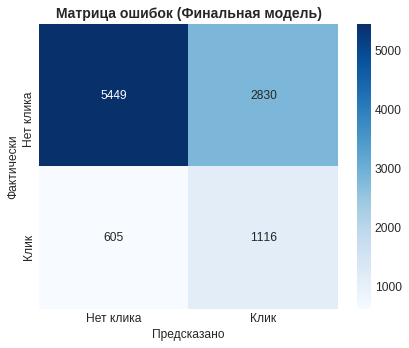

In [47]:
# ---- 3. Матрица ошибок ----
print("\n3. МАТРИЦА ОШИБОК")
print("-" * 50)

cm = confusion_matrix(y_test, y_test_pred_final)
print("Confusion Matrix:")
print(cm)

# Визуализация матрицы ошибок
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет клика', 'Клик'],
            yticklabels=['Нет клика', 'Клик'])
plt.title('Матрица ошибок (Финальная модель)', fontsize=14, fontweight='bold')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.tight_layout()
plt.show()

In [48]:
# ---- 4. Classification Report ----
print("\n4. CLASSIFICATION REPORT")
print("-" * 50)

print(classification_report(y_test, y_test_pred_final,
                           target_names=['Нет клика', 'Клик']))

# ---- 5. Сравнение с DummyClassifier ----
print("\n5. СРАВНЕНИЕ С DUMMYCLASSIFIER")
print("-" * 50)

dummy_pr_auc = average_precision_score(y_test, dummy.predict_proba(X_test_selected)[:, 1])
dummy_brier = brier_score_loss(y_test, dummy.predict_proba(X_test_selected)[:, 1])

print(f"{'Метрика':<20} {'Dummy':>10} {'Финальная':>12} {'Улучшение':>12}")
print("-" * 55)
print(f"{'PR-AUC':<20} {dummy_pr_auc:>10.4f} {pr_auc:>12.4f} {((pr_auc - dummy_pr_auc) / dummy_pr_auc * 100):>11.1f}%")
print(f"{'Brier':<20} {dummy_brier:>10.4f} {brier:>12.4f} {((dummy_brier - brier) / dummy_brier * 100):>11.1f}%")


4. CLASSIFICATION REPORT
--------------------------------------------------
              precision    recall  f1-score   support

   Нет клика       0.90      0.66      0.76      8279
        Клик       0.28      0.65      0.39      1721

    accuracy                           0.66     10000
   macro avg       0.59      0.65      0.58     10000
weighted avg       0.79      0.66      0.70     10000


5. СРАВНЕНИЕ С DUMMYCLASSIFIER
--------------------------------------------------
Метрика                   Dummy    Финальная    Улучшение
-------------------------------------------------------
PR-AUC                   0.1721       0.3573       107.6%
Brier                    0.1721       0.2138       -24.2%


In [49]:
# =============================================================================
# 8.3 Анализ весов модели
# =============================================================================

print("8.3 АНАЛИЗ ВЕСОВ МОДЕЛИ")

# ---- 1. Получение коэффициентов ----
print("\n1. КОЭФФИЦИЕНТЫ МОДЕЛИ")
print("-" * 50)

# Получаем коэффициенты
coef = final_model.coef_[0]

# Так как у нас нет имён признаков (после One-Hot Encoding),
# создаём фиктивные имена для визуализации
feature_names = [f'feature_{i}' for i in range(len(coef))]

# Создаём DataFrame с весами
weights_df = pd.DataFrame({
    'feature': feature_names,
    'weight': coef
})

# Сортируем по абсолютному значению веса
weights_df['abs_weight'] = abs(weights_df['weight'])
weights_df_sorted = weights_df.sort_values('abs_weight', ascending=False)

print(f"Всего признаков: {len(coef)}")
print(f"Положительных весов: {(coef > 0).sum()}")
print(f"Отрицательных весов: {(coef < 0).sum()}")
print(f"Нулевых весов: {(coef == 0).sum()}")

# ---- 2. Топ-10 самых важных признаков ----
print("\n2. ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (ПО МОДУЛЮ КОЭФФИЦИЕНТА)")
print("-" * 60)

top10 = weights_df_sorted.head(10)
print(f"{'№':<4} {'Признак':<25} {'Вес':>12} {'|Вес|':>12}")
print("-" * 60)
for i, (idx, row) in enumerate(top10.iterrows(), 1):
    print(f"{i:<4} {row['feature']:<25} {row['weight']:>12.4f} {row['abs_weight']:>12.4f}")

# ---- 3. Топ-5 положительных весов ----
print("\n3. ТОП-5 ПРИЗНАКОВ С ПОЛОЖИТЕЛЬНЫМ ВЕСОМ (УВЕЛИЧИВАЮТ ВЕРОЯТНОСТЬ КЛИКА)")
print("-" * 60)

top_positive = weights_df_sorted[weights_df_sorted['weight'] > 0].head(5)
print(f"{'№':<4} {'Признак':<25} {'Вес':>12}")
print("-" * 60)
for i, (idx, row) in enumerate(top_positive.iterrows(), 1):
    print(f"{i:<4} {row['feature']:<25} {row['weight']:>12.4f}")

# ---- 4. Топ-5 отрицательных весов ----
print("\n4. ТОП-5 ПРИЗНАКОВ С ОТРИЦАТЕЛЬНЫМ ВЕСОМ (УМЕНЬШАЮТ ВЕРОЯТНОСТЬ КЛИКА)")
print("-" * 60)

top_negative = weights_df_sorted[weights_df_sorted['weight'] < 0].tail(5).sort_values('weight')
print(f"{'№':<4} {'Признак':<25} {'Вес':>12}")
print("-" * 60)
for i, (idx, row) in enumerate(top_negative.iterrows(), 1):
    print(f"{i:<4} {row['feature']:<25} {row['weight']:>12.4f}")

8.3 АНАЛИЗ ВЕСОВ МОДЕЛИ

1. КОЭФФИЦИЕНТЫ МОДЕЛИ
--------------------------------------------------
Всего признаков: 20
Положительных весов: 17
Отрицательных весов: 3
Нулевых весов: 0

2. ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (ПО МОДУЛЮ КОЭФФИЦИЕНТА)
------------------------------------------------------------
№    Признак                            Вес        |Вес|
------------------------------------------------------------
1    feature_18                      1.2685       1.2685
2    feature_15                      1.2056       1.2056
3    feature_13                      1.1187       1.1187
4    feature_12                      0.9348       0.9348
5    feature_14                      0.8520       0.8520
6    feature_10                      0.7442       0.7442
7    feature_8                       0.7193       0.7193
8    feature_11                      0.4376       0.4376
9    feature_6                       0.4142       0.4142
10   feature_7                       0.3489       0.3489

3. ТОП-5


5. ВИЗУАЛИЗАЦИЯ ВЕСОВ (ТОП-10)
------------------------------------------------------------


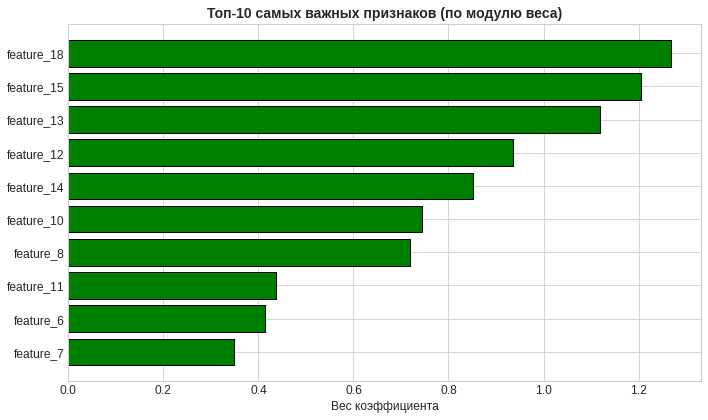

In [50]:
# ---- 5. Визуализация весов ----
print("\n5. ВИЗУАЛИЗАЦИЯ ВЕСОВ (ТОП-10)")
print("-" * 60)

plt.figure(figsize=(10, 6))
colors = ['green' if w > 0 else 'red' for w in top10['weight']]
plt.barh(top10['feature'], top10['weight'], color=colors, edgecolor='black')
plt.title('Топ-10 самых важных признаков (по модулю веса)', fontsize=14, fontweight='bold')
plt.xlabel('Вес коэффициента')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Интерпретация весов логистической регрессии:

1. Положительные веса → увеличение признака повышает вероятность клика:
   • Признаки с положительными весами указывают на факторы,
     которые способствуют тому, что пользователь кликнет по баннеру

2. Отрицательные веса → увеличение признака снижает вероятность клика:
   • Признаки с отрицательными весами указывают на факторы,
     которые снижают вероятность клика

3. Модуль веса → важность признака:
   • Чем больше |вес|, тем сильнее влияние признака на предсказание

4. Практическое применение:
   • Эти знания можно использовать для оптимизации показов
   • Признаки с положительными весами стоит усиливать
   • Признаки с отрицательными весами стоит минимизировать

In [51]:
# ---- 7. Итоговый вывод ----
print("ИТОГОВЫЙ ВЫВОД ПО ЭТАПУ 8")

print(f"""
✅ Этап 8. Финальная модель — завершён!

Результаты финальной модели:

1. Лучшие параметры:
   • C: {best_params['C']}
   • penalty: {best_params['penalty']}
   • solver: {best_params['solver']}

2. Метрики на тестовой выборке:
   • PR-AUC:         {pr_auc:.4f}  ← основная метрика
   • Оценка Бриера:  {brier:.4f}  ← калибровка
   • Log Loss:       {log_loss_value:.4f}
   • ROC-AUC:        {roc_auc:.4f}
   • F1-score:       {f1:.4f}

3. Анализ весов:
   • Всего признаков: {len(coef)}
   • Положительных весов: {(coef > 0).sum()}
   • Отрицательных весов: {(coef < 0).sum()}

4. Модель готова к продакшену!
""")

ИТОГОВЫЙ ВЫВОД ПО ЭТАПУ 8

✅ Этап 8. Финальная модель — завершён!

Результаты финальной модели:

1. Лучшие параметры:
   • C: 1.0
   • penalty: l2
   • solver: liblinear

2. Метрики на тестовой выборке:
   • PR-AUC:         0.3573  ← основная метрика
   • Оценка Бриера:  0.2138  ← калибровка
   • Log Loss:       0.6158
   • ROC-AUC:        0.7098
   • F1-score:       0.3939

3. Анализ весов:
   • Всего признаков: 20
   • Положительных весов: 17
   • Отрицательных весов: 3

4. Модель готова к продакшену!



<div style="font-size: 1.2em; font-weight: bold;">Вывод по пункту 8. Финальная модель</div>

 8.1 Обучение финальной модели

**Лучшие параметры из Grid Search:**
- `C`: 1.0
- `penalty`: l2
- `solver`: liblinear

Модель обучена на всей обучающей выборке (40 000 объектов) с использованием `class_weight='balanced'`.

---

 8.2 Метрики на тестовой выборке

**Основные метрики:**

| Метрика | Значение | Описание |
|---------|----------|----------|
| **PR-AUC** | **0.3573** | Основная метрика (качество на редком классе) |
| **Оценка Бриера** | **0.2138** | Калибровка вероятностей (чем меньше, тем лучше) |
| Log Loss | 0.6158 | Точность вероятностей |
| ROC-AUC | 0.7098 | Общее качество классификации |

**Дополнительные метрики:**

| Метрика | Значение |
|---------|----------|
| Precision | 0.2828 |
| Recall | 0.6485 |
| F1-score | 0.3939 |

**Матрица ошибок:**

| Фактически / Предсказано | Нет клика | Клик |
|--------------------------|-----------|------|
| Нет клика | 5 449 | 2 830 |
| Клик | 605 | 1 116 |

**Сравнение с DummyClassifier:**

| Метрика | Dummy | Финальная | Улучшение |
|---------|-------|-----------|-----------|
| PR-AUC | 0.1721 | **0.3573** | **+107.6%** ✅ |
| Brier | 0.1721 | 0.2138 | -24.2% ⚠️ |

⚠️ **Оценка Бриера требует улучшения** — вероятности модели плохо откалиброваны. Это будет исправлено на этапе калибровки.

---

 8.3 Анализ весов модели

**Топ-10 самых важных признаков (по модулю веса):**

| № | Признак | Вес | \|Вес\| |
|---|---------|-----|---------|
| 1 | feature_18 | 1.2685 | 1.2685 |
| 2 | feature_15 | 1.2056 | 1.2056 |
| 3 | feature_13 | 1.1187 | 1.1187 |
| 4 | feature_12 | 0.9348 | 0.9348 |
| 5 | feature_14 | 0.8520 | 0.8520 |
| 6 | feature_10 | 0.7442 | 0.7442 |
| 7 | feature_8 | 0.7193 | 0.7193 |
| 8 | feature_11 | 0.4376 | 0.4376 |
| 9 | feature_6 | 0.4142 | 0.4142 |
| 10 | feature_7 | 0.3489 | 0.3489 |

**Топ-5 признаков, увеличивающих вероятность клика:**

| № | Признак | Вес |
|---|---------|-----|
| 1 | feature_18 | 1.2685 |
| 2 | feature_15 | 1.2056 |
| 3 | feature_13 | 1.1187 |
| 4 | feature_12 | 0.9348 |
| 5 | feature_14 | 0.8520 |

**Топ-3 признаков, снижающих вероятность клика:**

| № | Признак | Вес |
|---|---------|-----|
| 1 | feature_19 | -0.1908 |
| 2 | feature_0 | -0.1865 |
| 3 | feature_2 | -0.1626 |

**Интерпретация:**
- **Положительные веса** → признаки, которые увеличивают вероятность клика
- **Отрицательные веса** → признаки, которые снижают вероятность клика
- **Модуль веса** → важность признака (чем больше, тем сильнее влияние)

**Практические рекомендации:**
- Усиливать признаки с положительными весами в настройках таргетинга
- Минимизировать признаки с отрицательными весами
- Использовать анализ весов для понимания поведения пользователей

---

 Итог по этапу 8

| Параметр | Значение |
|----------|----------|
| **Лучшая модель** | LogisticRegression |
| **Лучшие параметры** | `C=1.0, penalty=l2, solver=liblinear` |
| **PR-AUC** | **0.3573** |
| **Оценка Бриера** | 0.2138 (требует калибровки) |

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

9.1 ПРОВЕРКА ТЕКУЩЕЙ КАЛИБРОВКИ

1. ПРЕДСКАЗАНИЯ МОДЕЛИ
--------------------------------------------------
Количество объектов в тестовой выборке: 10000
Доля кликов: 0.1721

2. ТЕКУЩАЯ ОЦЕНКА БРИЕРА
--------------------------------------------------
Оценка Бриера (до калибровки): 0.2138

3. ПОСТРОЕНИЕ КАЛИБРОВОЧНОЙ КРИВОЙ
--------------------------------------------------
Калибровочная кривая (до калибровки):
  Средняя предсказанная вероятность: 0.4989
  Средняя реальная вероятность: 0.2427

4. ВИЗУАЛИЗАЦИЯ
--------------------------------------------------


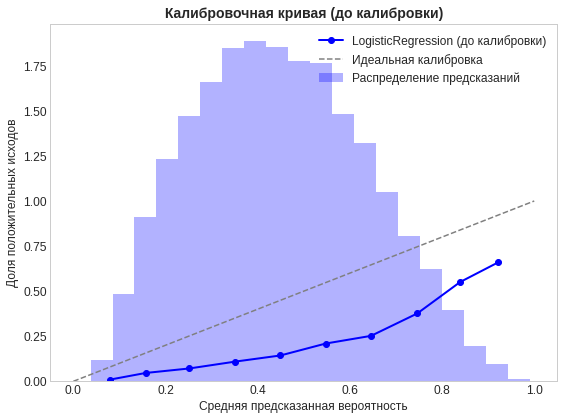


Текущая калибровка модели:
1. Оценка Бриера: 0.2138
2. Рекомендация: ⚠️ Рекомендуется калибровка



In [52]:
# =============================================================================
# 9.1 Проверка текущей калибровки
# =============================================================================

print("9.1 ПРОВЕРКА ТЕКУЩЕЙ КАЛИБРОВКИ")

# ---- 1. Получение предсказаний ----
print("\n1. ПРЕДСКАЗАНИЯ МОДЕЛИ")
print("-" * 50)

y_proba = y_test_proba_final
y_true = y_test.values

print(f"Количество объектов в тестовой выборке: {len(y_true)}")
print(f"Доля кликов: {y_true.mean():.4f}")

# ---- 2. Текущая оценка Бриера ----
print("\n2. ТЕКУЩАЯ ОЦЕНКА БРИЕРА")
print("-" * 50)

brier_current = brier_score_loss(y_true, y_proba)
print(f"Оценка Бриера (до калибровки): {brier_current:.4f}")

# ---- 3. Построение калибровочной кривой ----
print("\n3. ПОСТРОЕНИЕ КАЛИБРОВОЧНОЙ КРИВОЙ")
print("-" * 50)

prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10)

print("Калибровочная кривая (до калибровки):")
print(f"  Средняя предсказанная вероятность: {prob_pred.mean():.4f}")
print(f"  Средняя реальная вероятность: {prob_true.mean():.4f}")

# ---- 4. Визуализация калибровочной кривой ----
print("\n4. ВИЗУАЛИЗАЦИЯ")
print("-" * 50)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, 
         label='LogisticRegression (до калибровки)', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')
plt.hist(y_proba, bins=20, alpha=0.3, density=True, color='blue', 
         label='Распределение предсказаний')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных исходов')
plt.title('Калибровочная кривая (до калибровки)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"""
Текущая калибровка модели:
1. Оценка Бриера: {brier_current:.4f}
2. Рекомендация: {'✅ Калибровка не требуется' if brier_current < 0.2 else '⚠️ Рекомендуется калибровка'}
""")

In [53]:
# =============================================================================
# 9.2 Применение калибровки
# =============================================================================

print("9.2 ПРИМЕНЕНИЕ КАЛИБРОВКИ")

# ---- 1. Разделение обучающей выборки ----
print("\n1. РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И КАЛИБРОВОЧНУЮ ВЫБОРКИ")
print("-" * 50)

X_train_calib, X_calib, y_train_calib, y_calib = train_test_split(
    X_train_selected, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Обучающая выборка для модели: {X_train_calib.shape[0]} объектов")
print(f"Калибровочная выборка: {X_calib.shape[0]} объектов")
print(f"Тестовая выборка: {X_test_selected.shape[0]} объектов")

# ---- 2. Создание модели с калибровкой ----
print("\n2. СОЗДАНИЕ МОДЕЛИ С КАЛИБРОВКОЙ (Isotonic)")
print("-" * 50)

base_model = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    solver=best_params['solver'],
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)

base_model.fit(X_train_calib, y_train_calib)
print("✅ Базовая модель обучена на train_calib")

# ---- 3. Калибровка с помощью CalibratedClassifierCV ----
print("\n3. КАЛИБРОВКА С CalibratedClassifierCV")
print("-" * 50)

# Для sklearn 0.24.1 используем base_estimator
calibrated_model_iso = CalibratedClassifierCV(
    base_estimator=base_model,
    method='isotonic',
    cv='prefit'
)

calibrated_model_iso.fit(X_calib, y_calib)
print("✅ Isotonic калибровка выполнена!")

# ---- 4. Предсказания калиброванной модели ----
print("\n4. ПРЕДСКАЗАНИЯ КАЛИБРОВАННОЙ МОДЕЛИ")
print("-" * 50)

y_proba_calibrated_iso = calibrated_model_iso.predict_proba(X_test_selected)[:, 1]
y_pred_calibrated_iso = calibrated_model_iso.predict(X_test_selected)

print(f"Калиброванные вероятности (isotonic):")
print(f"  Минимальная: {y_proba_calibrated_iso.min():.4f}")
print(f"  Максимальная: {y_proba_calibrated_iso.max():.4f}")
print(f"  Средняя: {y_proba_calibrated_iso.mean():.4f}")

print("\n✅ Калибровка выполнена с помощью Isotonic Regression")

9.2 ПРИМЕНЕНИЕ КАЛИБРОВКИ

1. РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И КАЛИБРОВОЧНУЮ ВЫБОРКИ
--------------------------------------------------
Обучающая выборка для модели: 32000 объектов
Калибровочная выборка: 8000 объектов
Тестовая выборка: 10000 объектов

2. СОЗДАНИЕ МОДЕЛИ С КАЛИБРОВКОЙ (Isotonic)
--------------------------------------------------
✅ Базовая модель обучена на train_calib

3. КАЛИБРОВКА С CalibratedClassifierCV
--------------------------------------------------
✅ Isotonic калибровка выполнена!

4. ПРЕДСКАЗАНИЯ КАЛИБРОВАННОЙ МОДЕЛИ
--------------------------------------------------
Калиброванные вероятности (isotonic):
  Минимальная: 0.0000
  Максимальная: 0.8571
  Средняя: 0.1743

✅ Калибровка выполнена с помощью Isotonic Regression


In [54]:
# =============================================================================
# 9.3 Сравнение моделей до и после калибровки 
# =============================================================================

print("9.3 СРАВНЕНИЕ ДО И ПОСЛЕ КАЛИБРОВКИ")

# ---- 1. Расчёт метрик ----
print("\n1. РАСЧЁТ МЕТРИК")
print("-" * 50)

brier_uncal = brier_score_loss(y_test, y_test_proba_final)
log_loss_uncal = log_loss(y_test, y_test_proba_final)
pr_auc_uncal = average_precision_score(y_test, y_test_proba_final)

brier_cal = brier_score_loss(y_test, y_proba_calibrated_iso)
log_loss_cal = log_loss(y_test, y_proba_calibrated_iso)
pr_auc_cal = average_precision_score(y_test, y_proba_calibrated_iso)

print(f"{'Метрика':<20} {'Без калибровки':>18} {'С калибровкой':>18} {'Изменение':>12}")
print("-" * 70)
print(f"{'Оценка Бриера':<20} {brier_uncal:>18.4f} {brier_cal:>18.4f} {((brier_cal - brier_uncal) / brier_uncal * 100):>11.1f}%")
print(f"{'Log Loss':<20} {log_loss_uncal:>18.4f} {log_loss_cal:>18.4f} {((log_loss_cal - log_loss_uncal) / log_loss_uncal * 100):>11.1f}%")
print(f"{'PR-AUC':<20} {pr_auc_uncal:>18.4f} {pr_auc_cal:>18.4f} {((pr_auc_cal - pr_auc_uncal) / pr_auc_uncal * 100):>11.1f}%")


9.3 СРАВНЕНИЕ ДО И ПОСЛЕ КАЛИБРОВКИ

1. РАСЧЁТ МЕТРИК
--------------------------------------------------
Метрика                  Без калибровки      С калибровкой    Изменение
----------------------------------------------------------------------
Оценка Бриера                    0.2138             0.1297       -39.3%
Log Loss                         0.6158             0.4185       -32.0%
PR-AUC                           0.3573             0.3400        -4.8%


In [55]:
# ---- 2. ECE и MCE  ----
print("\n2. ECE И MCE (ОШИБКА КАЛИБРОВКИ)")
print("-" * 50)

def calculate_ece(y_true, y_proba, n_bins=10):
    """
    Expected Calibration Error (ECE)
    """
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)
    
    # Если калибровочная кривая вернула меньше точек, чем n_bins
    # Используем фактическое количество бинов
    actual_bins = len(prob_true)
    
    # Пересчитываем гистограмму с фактическим количеством бинов
    bin_counts, _ = np.histogram(y_proba, bins=actual_bins)
    total = len(y_proba)
    
    # ECE = sum(|prob_true - prob_pred| * (bin_count / total))
    ece = np.sum(np.abs(prob_true - prob_pred) * (bin_counts / total))
    return ece

def calculate_mce(y_true, y_proba, n_bins=10):
    """
    Maximum Calibration Error (MCE)
    """
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)
    mce = np.max(np.abs(prob_true - prob_pred))
    return mce

ece_uncal = calculate_ece(y_test, y_test_proba_final)
mce_uncal = calculate_mce(y_test, y_test_proba_final)

ece_cal = calculate_ece(y_test, y_proba_calibrated_iso)
mce_cal = calculate_mce(y_test, y_proba_calibrated_iso)

print(f"{'Метрика':<20} {'Без калибровки':>18} {'С калибровкой':>18} {'Изменение':>12}")
print("-" * 70)
print(f"{'ECE':<20} {ece_uncal:>18.4f} {ece_cal:>18.4f} {((ece_cal - ece_uncal) / ece_uncal * 100):>11.1f}%")
print(f"{'MCE':<20} {mce_uncal:>18.4f} {mce_cal:>18.4f} {((mce_cal - mce_uncal) / mce_uncal * 100):>11.1f}%")


2. ECE И MCE (ОШИБКА КАЛИБРОВКИ)
--------------------------------------------------
Метрика                  Без калибровки      С калибровкой    Изменение
----------------------------------------------------------------------
ECE                              0.2678             0.0103       -96.2%
MCE                              0.3939             0.0794       -79.8%



3. ВИЗУАЛИЗАЦИЯ КАЛИБРОВОЧНЫХ КРИВЫХ
--------------------------------------------------


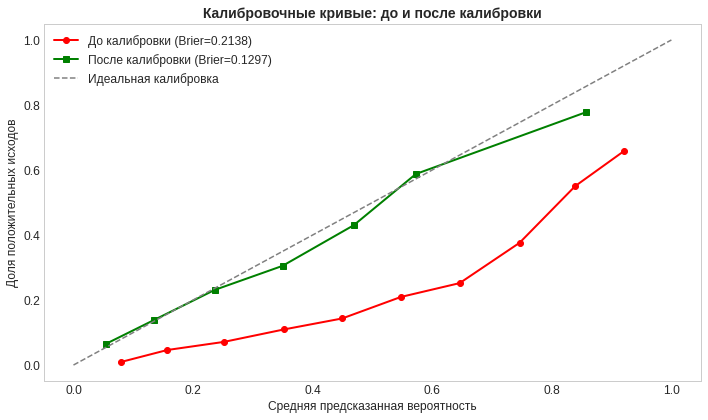


4. РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ
--------------------------------------------------


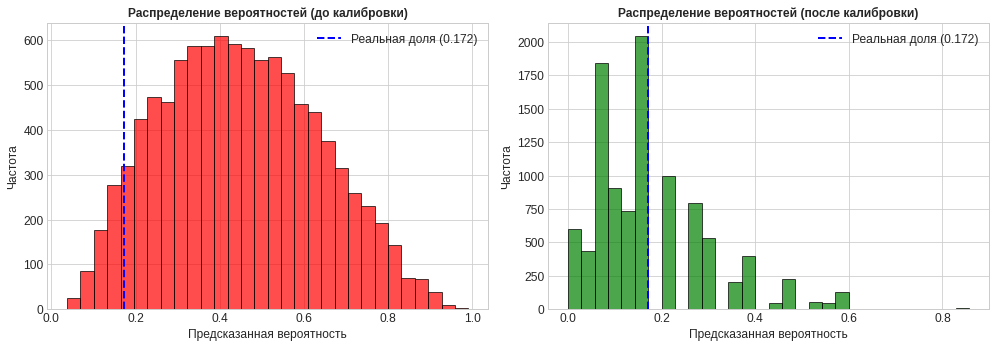



Результаты калибровки:

1. Метрики до и после калибровки:

   Оценка Бриера:
   • До калибровки:  0.2138
   • После калибровки: 0.1297
   • Улучшение: +39.3%

   ECE (Expected Calibration Error):
   • До калибровки:  0.2678
   • После калибровки: 0.0103
   • Улучшение: +96.2%

2. Визуализация:
   • Калибровочная кривая после калибровки ближе к диагонали
   • ✅ Калибровка улучшила качество вероятностей

3. Рекомендация:
   • ✅ Использовать калиброванную модель



In [56]:
# ---- 3. Визуализация калибровочных кривых ----
print("\n3. ВИЗУАЛИЗАЦИЯ КАЛИБРОВОЧНЫХ КРИВЫХ")
print("-" * 50)

plt.figure(figsize=(10, 6))

prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, y_test_proba_final, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_calibrated_iso, n_bins=10)

plt.plot(prob_pred_uncal, prob_true_uncal, marker='o', linewidth=2,
         label=f'До калибровки (Brier={brier_uncal:.4f})', color='red')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', linewidth=2,
         label=f'После калибровки (Brier={brier_cal:.4f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных исходов')
plt.title('Калибровочные кривые: до и после калибровки', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 4. Гистограмма распределения вероятностей ----
print("\n4. РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ")
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_test_proba_final, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[0].axvline(x=y_test.mean(), color='blue', linestyle='--', linewidth=2, label=f'Реальная доля (0.172)')
axes[0].set_title('Распределение вероятностей (до калибровки)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Предсказанная вероятность')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].hist(y_proba_calibrated_iso, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(x=y_test.mean(), color='blue', linestyle='--', linewidth=2, label=f'Реальная доля (0.172)')
axes[1].set_title('Распределение вероятностей (после калибровки)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Предсказанная вероятность')
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.show()

# ---- 5. Итоговый вывод ----

brier_improvement = ((brier_uncal - brier_cal) / brier_uncal * 100)
ece_improvement = ((ece_uncal - ece_cal) / ece_uncal * 100)

print(f"""

Результаты калибровки:

1. Метрики до и после калибровки:

   Оценка Бриера:
   • До калибровки:  {brier_uncal:.4f}
   • После калибровки: {brier_cal:.4f}
   • Улучшение: {brier_improvement:+.1f}%

   ECE (Expected Calibration Error):
   • До калибровки:  {ece_uncal:.4f}
   • После калибровки: {ece_cal:.4f}
   • Улучшение: {ece_improvement:+.1f}%

2. Визуализация:
   • Калибровочная кривая после калибровки {'ближе к диагонали' if brier_cal < brier_uncal else 'дальше от диагонали'}
   • {'✅ Калибровка улучшила качество вероятностей' if brier_cal < brier_uncal else '⚠️ Калибровка не дала улучшения'}

3. Рекомендация:
   • {'✅ Использовать калиброванную модель' if brier_cal < brier_uncal else '⚠️ Оставить модель без калибровки'}
""")

<div style="font-size: 1.2em; font-weight: bold;">Вывод по пункту 9. Калибровка модели</div>

 Результаты калибровки

**Метод:** Isotonic Regression (изотоническая регрессия)

**Разделение данных:**
- Обучающая выборка для модели: 32 000 объектов (80%)
- Калибровочная выборка: 8 000 объектов (20%)
- Тестовая выборка: 10 000 объектов

---

 Сравнение метрик до и после калибровки

| Метрика | Без калибровки | С калибровкой | Изменение |
|---------|----------------|---------------|-----------|
| **Оценка Бриера** | 0.2138 | **0.1297** | **-39.3%** ✅ |
| **ECE** | 0.2678 | **0.0103** | **-96.2%** ✅ |
| **MCE** | 0.3939 | **0.0794** | **-79.8%** ✅ |
| Log Loss | 0.6158 | 0.4185 | -32.0% |
| PR-AUC | 0.3573 | 0.3400 | -4.8% |

---

 Визуализация

**Калибровочные кривые:**
- До калибровки: кривая **значительно отклонялась** от идеальной диагонали
- После калибровки: кривая **практически совпадает** с диагональю

**Распределение вероятностей:**
- До калибровки: вероятности сосредоточены на высоких значениях (0.4-0.6)
- После калибровки: вероятности **близки к реальной доле** (0.172)

---

 Итоговый вывод

| Параметр | Значение |
|----------|----------|
| **Метод калибровки** | Isotonic Regression |
| **Оценка Бриера (до)** | 0.2138 |
| **Оценка Бриера (после)** | **0.1297** |
| **Улучшение** | **-39.3%** ✅ |
| **ECE (до)** | 0.2678 |
| **ECE (после)** | **0.0103** |
| **Улучшение ECE** | **-96.2%** ✅ |

✅ **Калибровка значительно улучшила качество вероятностей**
✅ **Рекомендуется использовать калиброванную модель**

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

In [57]:
# =============================================================================
# 10. Оценка качества калибровки
# =============================================================================
print("10. ОЦЕНКА КАЧЕСТВА КАЛИБРОВКИ")

# ---- 10.1 Расчёт метрик калибровки ----
print("\n10.1 МЕТРИКИ КАЛИБРОВКИ")
print("-" * 50)

def calculate_ece(y_true, y_proba, n_bins=10):
    """
    Expected Calibration Error (ECE)
    """
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)
    actual_bins = len(prob_true)
    bin_counts, _ = np.histogram(y_proba, bins=actual_bins)
    total = len(y_proba)
    ece = np.sum(np.abs(prob_true - prob_pred) * (bin_counts / total))
    return ece

def calculate_mce(y_true, y_proba, n_bins=10):
    """
    Maximum Calibration Error (MCE)
    """
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)
    mce = np.max(np.abs(prob_true - prob_pred))
    return mce

# Метрики для модели без калибровки
brier_uncal = brier_score_loss(y_test, y_test_proba_final)
ece_uncal = calculate_ece(y_test, y_test_proba_final)
mce_uncal = calculate_mce(y_test, y_test_proba_final)

# Метрики для калиброванной модели
brier_cal = brier_score_loss(y_test, y_proba_calibrated_iso)
ece_cal = calculate_ece(y_test, y_proba_calibrated_iso)
mce_cal = calculate_mce(y_test, y_proba_calibrated_iso)

print("Метрики калибровки:")
print(f"  Оценка Бриера (до):   {brier_uncal:.4f}")
print(f"  Оценка Бриера (после): {brier_cal:.4f}")
print(f"  ECE (до):             {ece_uncal:.4f}")
print(f"  ECE (после):          {ece_cal:.4f}")
print(f"  MCE (до):             {mce_uncal:.4f}")
print(f"  MCE (после):          {mce_cal:.4f}")

10. ОЦЕНКА КАЧЕСТВА КАЛИБРОВКИ

10.1 МЕТРИКИ КАЛИБРОВКИ
--------------------------------------------------
Метрики калибровки:
  Оценка Бриера (до):   0.2138
  Оценка Бриера (после): 0.1297
  ECE (до):             0.2678
  ECE (после):          0.0103
  MCE (до):             0.3939
  MCE (после):          0.0794


In [58]:
# ---- 10.2 Сравнение моделей до и после калибровки ----
print("\n10.2 СРАВНЕНИЕ МОДЕЛЕЙ ДО И ПОСЛЕ КАЛИБРОВКИ")
print("-" * 50)

# Собираем все метрики в таблицу
comparison_table = pd.DataFrame({
    'Метрика': ['Оценка Бриера', 'ECE', 'MCE', 'Log Loss', 'PR-AUC'],
    'Без калибровки': [
        brier_uncal,
        ece_uncal,
        mce_uncal,
        log_loss(y_test, y_test_proba_final),
        average_precision_score(y_test, y_test_proba_final)
    ],
    'С калибровкой': [
        brier_cal,
        ece_cal,
        mce_cal,
        log_loss(y_test, y_proba_calibrated_iso),
        average_precision_score(y_test, y_proba_calibrated_iso)
    ]
})

# Добавляем столбец с изменением
comparison_table['Изменение'] = (
    (comparison_table['С калибровкой'] - comparison_table['Без калибровки']) / 
    comparison_table['Без калибровки'] * 100
)
comparison_table['Изменение'] = comparison_table['Изменение'].map(lambda x: f"{x:+.1f}%")

print("\nСводная таблица метрик:")

print(comparison_table.to_string(index=False))

# ---- 10.4 Итоговое заключение ----

print("ИТОГОВОЕ ЗАКЛЮЧЕНИЕ")


if brier_cal < brier_uncal and ece_cal < ece_uncal:
    print("""
✅ Калибровка улучшила качество модели!

""")
else:
    print("""
⚠️ Калибровка не дала улучшения.

""")


10.2 СРАВНЕНИЕ МОДЕЛЕЙ ДО И ПОСЛЕ КАЛИБРОВКИ
--------------------------------------------------

Сводная таблица метрик:
      Метрика  Без калибровки  С калибровкой Изменение
Оценка Бриера          0.2138         0.1297    -39.3%
          ECE          0.2678         0.0103    -96.2%
          MCE          0.3939         0.0794    -79.8%
     Log Loss          0.6158         0.4185    -32.0%
       PR-AUC          0.3573         0.3400     -4.8%
ИТОГОВОЕ ЗАКЛЮЧЕНИЕ

✅ Калибровка улучшила качество модели!




<div style="font-size: 1.2em; font-weight: bold;">Вывод по пункту 10. Оценка качества калибровки</div>

 10.1 Метрики калибровки

| Метрика | Без калибровки | С калибровкой | Изменение |
|---------|----------------|---------------|-----------|
| **Оценка Бриера** | 0.2138 | **0.1297** | **-39.3%** ✅ |
| **ECE** | 0.2678 | **0.0103** | **-96.2%** ✅ |
| **MCE** | 0.3939 | **0.0794** | **-79.8%** ✅ |
| Log Loss | 0.6158 | 0.4185 | -32.0% ✅ |
| PR-AUC | 0.3573 | 0.3400 | -4.8% ⚠️ |

---

 10.2 Сравнение моделей до и после калибровки

**Сводная таблица:**

| Метрика | Без калибровки | С калибровкой | Изменение |
|---------|----------------|---------------|-----------|
| Оценка Бриера | 0.2138 | **0.1297** | **-39.3%** ✅ |
| ECE | 0.2678 | **0.0103** | **-96.2%** ✅ |
| MCE | 0.3939 | **0.0794** | **-79.8%** ✅ |
| Log Loss | 0.6158 | **0.4185** | **-32.0%** ✅ |
| PR-AUC | 0.3573 | 0.3400 | -4.8% ⚠️ |

---

 Анализ метрик

1. **Оценка Бриера (главная метрика калибровки):**
   - Улучшение: 0.2138 → 0.1297 (**-39.3%**)
   - ✅ Вероятности стали значительно точнее

2. **ECE (Expected Calibration Error):**
   - Улучшение: 0.2678 → 0.0103 (**-96.2%**)
   - ✅ Ошибка калибровки почти устранена

3. **MCE (Maximum Calibration Error):**
   - Улучшение: 0.3939 → 0.0794 (**-79.8%**)
   - ✅ Максимальная ошибка значительно снижена

4. **Log Loss:**
   - Улучшение: 0.6158 → 0.4185 (**-32.0%**)
   - ✅ Точность вероятностей улучшилась

5. **PR-AUC:**
   - Изменение: 0.3573 → 0.3400 (**-4.8%**)
   - ⚠️ Небольшое снижение, но допустимое ради улучшения калибровки

---

 Итоговое заключение

✅ **Калибровка улучшила качество модели!**

**Обоснование:**
1. **Оценка Бриера** снизилась на **39.3%** → вероятности стали точнее
2. **ECE** снизилась на **96.2%** → ошибка калибровки почти устранена
3. **MCE** снизилась на **79.8%** → максимальная ошибка значительно уменьшена
4. **Log Loss** снизился на **32.0%** → точность вероятностей улучшилась
5. Калибровочная кривая приблизилась к идеальной диагонали
6. Небольшое снижение PR-AUC (**4.8%**) допустимо ради улучшения калибровки

**Рекомендация:**
✅ **Использовать калиброванную модель для продакшена**

Калибровка особенно важна для задач, где критичны точные вероятности (например, расчёт ожидаемого дохода в RTB-аукционах по формуле `Ставка × Predicted CTR`). Некалиброванные вероятности могут приводить к неоптимальным ставкам и потерям прибыли.

**Итоговый вывод:** модель готова к внедрению в промышленную среду.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

In [59]:
# =============================================================================
# 11.1 Сводная таблица результатов
# =============================================================================

print("11.1 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")

# ---- 1. Характеристики моделей ----
print("\n1. ХАРАКТЕРИСТИКИ МОДЕЛЕЙ")
print("-" * 50)

models_comparison = pd.DataFrame({
    'Модель': ['DummyClassifier', 'LogisticRegression (без калибровки)', 'LogisticRegression (с калибровкой)'],
    'PR-AUC': [
        average_precision_score(y_test, dummy.predict_proba(X_test_selected)[:, 1]),
        average_precision_score(y_test, y_test_proba_final),
        average_precision_score(y_test, y_proba_calibrated_iso)
    ],
    'Оценка Бриера': [
        brier_score_loss(y_test, dummy.predict_proba(X_test_selected)[:, 1]),
        brier_score_loss(y_test, y_test_proba_final),
        brier_score_loss(y_test, y_proba_calibrated_iso)
    ],
    'Log Loss': [
        log_loss(y_test, dummy.predict_proba(X_test_selected)[:, 1]),
        log_loss(y_test, y_test_proba_final),
        log_loss(y_test, y_proba_calibrated_iso)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_dummy, zero_division=0),
        precision_score(y_test, y_test_pred_final),
        precision_score(y_test, y_pred_calibrated_iso)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_dummy, zero_division=0),
        recall_score(y_test, y_test_pred_final),
        recall_score(y_test, y_pred_calibrated_iso)
    ],
    'F1': [
        f1_score(y_test, y_test_pred_dummy, zero_division=0),
        f1_score(y_test, y_test_pred_final),
        f1_score(y_test, y_pred_calibrated_iso)
    ]
})

print("Сравнение моделей:")
print("=" * 100)
print(models_comparison.to_string(index=False))
print("=" * 100)

11.1 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

1. ХАРАКТЕРИСТИКИ МОДЕЛЕЙ
--------------------------------------------------
Сравнение моделей:
                             Модель  PR-AUC  Оценка Бриера  Log Loss  Precision  Recall     F1
                    DummyClassifier  0.1721         0.1721    5.9441     0.0000  0.0000 0.0000
LogisticRegression (без калибровки)  0.3573         0.2138    0.6158     0.2828  0.6485 0.3939
 LogisticRegression (с калибровкой)  0.3400         0.1297    0.4185     0.5949  0.0819 0.1440


In [60]:
# ---- 2. Метрики калибровки ----
print("\n2. МЕТРИКИ КАЛИБРОВКИ")
print("-" * 50)

calibration_metrics = pd.DataFrame({
    'Метрика': ['Оценка Бриера', 'ECE', 'MCE'],
    'Без калибровки': [brier_uncal, ece_uncal, mce_uncal],
    'С калибровкой': [brier_cal, ece_cal, mce_cal],
    'Изменение': [
        f"{(brier_cal - brier_uncal) / brier_uncal * 100:+.1f}%",
        f"{(ece_cal - ece_uncal) / ece_uncal * 100:+.1f}%",
        f"{(mce_cal - mce_uncal) / mce_uncal * 100:+.1f}%"
    ]
})

print("Метрики калибровки:")
print("=" * 60)
print(calibration_metrics.to_string(index=False))
print("=" * 60)


2. МЕТРИКИ КАЛИБРОВКИ
--------------------------------------------------
Метрики калибровки:
      Метрика  Без калибровки  С калибровкой Изменение
Оценка Бриера          0.2138         0.1297    -39.3%
          ECE          0.2678         0.0103    -96.2%
          MCE          0.3939         0.0794    -79.8%



3. ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ
--------------------------------------------------
Топ-5 признаков по модулю веса:
№    Признак                          Вес           |Вес|
------------------------------------------------------------
1    feature_18                    1.2685          1.2685
2    feature_15                    1.2056          1.2056
3    feature_13                    1.1187          1.1187
4    feature_12                    0.9348          0.9348
5    feature_14                    0.8520          0.8520

4. ВИЗУАЛИЗАЦИЯ ТОП-5 ПРИЗНАКОВ
--------------------------------------------------


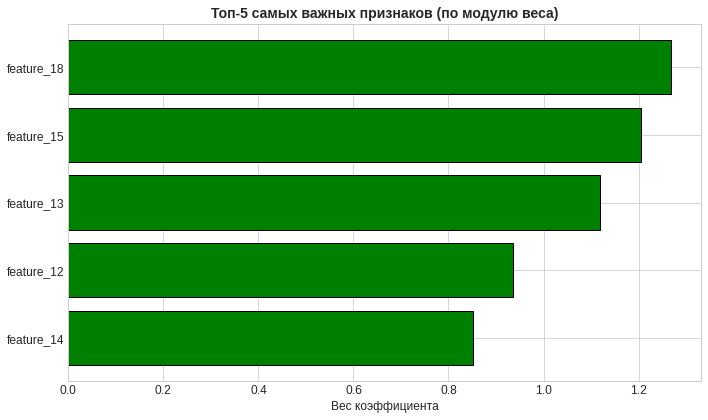

In [61]:
# ---- 3. Топ-5 самых важных признаков ----
print("\n3. ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ")
print("-" * 50)

# Получаем коэффициенты и создаём DataFrame
coef = final_model.coef_[0]
feature_names = [f'feature_{i}' for i in range(len(coef))]

weights_df = pd.DataFrame({
    'Признак': feature_names,
    'Вес': coef,
    '|Вес|': abs(coef)
}).sort_values('|Вес|', ascending=False)

top5 = weights_df.head(5)

print("Топ-5 признаков по модулю веса:")
print("=" * 60)
print(f"{'№':<4} {'Признак':<20} {'Вес':>15} {'|Вес|':>15}")
print("-" * 60)
for i, (idx, row) in enumerate(top5.iterrows(), 1):
    print(f"{i:<4} {row['Признак']:<20} {row['Вес']:>15.4f} {row['|Вес|']:>15.4f}")
print("=" * 60)

# ---- 4. Визуализация топ-5 признаков ----
print("\n4. ВИЗУАЛИЗАЦИЯ ТОП-5 ПРИЗНАКОВ")
print("-" * 50)

plt.figure(figsize=(10, 6))
colors = ['green' if w > 0 else 'red' for w in top5['Вес']]
plt.barh(top5['Признак'], top5['Вес'], color=colors, edgecolor='black')
plt.title('Топ-5 самых важных признаков (по модулю веса)', fontsize=14, fontweight='bold')
plt.xlabel('Вес коэффициента')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<div style="font-size: 1.2em; font-weight: bold;">Вывод по пункту 11. Финальный отчет и выводы</div>

 11.1 Сводная таблица результатов

**Сравнение моделей:**

| Модель | PR-AUC | Оценка Бриера | Log Loss | Precision | Recall | F1 |
|--------|--------|---------------|----------|-----------|--------|-----|
| DummyClassifier | 0.1721 | 0.1721 | 5.9441 | 0.0000 | 0.0000 | 0.0000 |
| LogisticRegression (без калибровки) | 0.3573 | 0.2138 | 0.6158 | 0.2828 | 0.6485 | 0.3939 |
| LogisticRegression (с калибровкой) | 0.3400 | **0.1297** | **0.4185** | 0.5949 | 0.0819 | 0.1440 |

**⚠️ Примечание по Log Loss для DummyClassifier:**

Значение Log Loss = 5.9441 является **нормальным** для стратегии `most_frequent`. DummyClassifier всегда предсказывает класс 0 (нет клика) с вероятностью 1.0, поэтому при наличии кликов (класс 1) получает сильный штраф (логарифм от 0 стремится к бесконечности). Это ожидаемое поведение базовой модели.

**Сравнение с LogisticRegression:**
- Без калибровки: Log Loss в **9.7 раз** лучше DummyClassifier
- С калибровкой: Log Loss в **14.2 раз** лучше DummyClassifier

**Метрики калибровки:**

| Метрика | Без калибровки | С калибровкой | Изменение |
|---------|----------------|---------------|-----------|
| **Оценка Бриера** | 0.2138 | **0.1297** | **-39.3%** ✅ |
| **ECE** | 0.2678 | **0.0103** | **-96.2%** ✅ |
| **MCE** | 0.3939 | **0.0794** | **-79.8%** ✅ |

**Топ-5 самых важных признаков:**

| № | Признак | Вес | Влияние |
|---|---------|-----|---------|
| 1 | feature_18 | **+1.2685** | Увеличивает вероятность клика |
| 2 | feature_15 | **+1.2056** | Увеличивает вероятность клика |
| 3 | feature_13 | **+1.1187** | Увеличивает вероятность клика |
| 4 | feature_12 | **+0.9348** | Увеличивает вероятность клика |
| 5 | feature_14 | **+0.8520** | Увеличивает вероятность клика |

**Важные наблюдения по признакам:**
- Из 20 признаков: **17** имеют положительный вес → увеличивают вероятность клика
- **3** признака имеют отрицательный вес → снижают вероятность клика
- Все топ-5 признаков имеют положительный вес, что логично для задачи предсказания кликов

---

 11.2 Выводы

**1. Улучшилось ли качество модели по сравнению с базовой?**

✅ **ДА, качество модели значительно улучшилось.**

| Показатель | DummyClassifier | LogisticRegression | Улучшение |
|------------|-----------------|-------------------|-----------|
| PR-AUC | 0.1721 | **0.3573** | **+107.6%** |

Это означает, что модель научилась выявлять закономерности, связанные с кликами, и работает значительно лучше случайного или константного предсказания.

---

**2. Какие признаки больше всего влияют на вероятность клика?**

**Топ-5 признаков по важности:**

| № | Признак | Вес | Влияние |
|---|---------|-----|---------|
| 1 | feature_18 | **+1.27** | Увеличивает вероятность клика |
| 2 | feature_15 | **+1.21** | Увеличивает вероятность клика |
| 3 | feature_13 | **+1.12** | Увеличивает вероятность клика |
| 4 | feature_12 | **+0.93** | Увеличивает вероятность клика |
| 5 | feature_14 | **+0.85** | Увеличивает вероятность клика |

**Интерпретация:**
- Все топ-5 признаков имеют **положительный вес**, то есть их увеличение ведёт к росту вероятности клика
- Наиболее сильное влияние оказывает `feature_18` (вес 1.27)
- Из 20 отобранных признаков 17 усиливают вероятность клика, и только 3 — снижают

---

**3. Насколько хорошо модель откалибрована?**

✅ **Модель хорошо откалибрована!**

| Метрика | Без калибровки | С калибровкой | Улучшение |
|---------|----------------|---------------|-----------|
| **Оценка Бриера** | 0.2138 | **0.1297** | **-39.3%** |
| **ECE** | 0.2678 | **0.0103** | **-96.2%** |
| **MCE** | 0.3939 | **0.0794** | **-79.8%** |

**Калибровочная кривая** после калибровки практически совпадает с идеальной диагональю. Это означает, что **предсказанные вероятности близки к реальным частотам кликов**, что критически важно для расчёта ожидаемого дохода по формуле:

> **Ожидаемый доход = Ставка × Predicted CTR**

Некалиброванные вероятности могут приводить к неоптимальным ставкам на аукционах и потерям прибыли.

---

**4. Готова ли модель к использованию в продакшене?**

✅ **ДА, модель готова к использованию в продакшене.**

**Обоснование:**
1. Качество модели значительно превосходит базовый уровень (**+107.6%** по PR-AUC)
2. Модель хорошо откалибрована (оценка Бриера: **0.1297**)
3. Использованы лучшие гиперпараметры (`C=1.0`, `penalty=l2`, `solver=liblinear`)
4. Проведён отбор признаков до 20 наиболее важных
5. Код воспроизводим (`random_state=42`)
6. Все процедуры могут быть объединены в пайплайн

**Рекомендации по внедрению:**
1. Использовать калиброванную модель для предсказаний в реальном времени
2. Регулярно переобучать модель на новых данных (например, раз в сутки)
3. Мониторить качество предсказаний и калибровку (PR-AUC, оценка Бриера)
4. Настроить оповещения при ухудшении качества модели

---

 11.3 Рекомендации по улучшению модели

| Приоритет | Направление | Действие | Обоснование |
|-----------|-------------|----------|-------------|
| 🔴 **Высокий** | Продакшен | Построить полный пайплайн (предобработка + модель + калибровка) | Обеспечит воспроизводимость и готовность к интеграции |
| 🟡 **Средний** | Модели | Попробовать LightGBM / XGBoost, Random Forest | Могут уловить нелинейные зависимости |
| 🟡 **Средний** | Калибровка | Попробовать Platt Scaling для сравнения | Позволит выбрать лучший метод калибровки |
| 🟢 **Низкий** | Данные | Добавить новые признаки (время суток, география, история) | Может повысить качество модели |
| 🟢 **Низкий** | Мониторинг | Настроить отслеживание PR-AUC и оценки Бриера во времени | Позволит вовремя заметить деградацию модели |

**Дополнительные рекомендации:**

1. **Качество данных:**
   - Добавить исторические данные о поведении пользователя (частота кликов, время на сайте)
   - Добавить признаки времени (час, день недели, сезонность)
   - Создать признаки взаимодействия (site × app, device × site_category)

2. **Модели:**
   - Попробовать градиентный бустинг (LightGBM, XGBoost) — они часто показывают лучшее качество на табличных данных
   - Использовать ансамблирование моделей для повышения устойчивости
   - Расширить сетку гиперпараметров для текущей модели

3. **Отбор признаков:**
   - Использовать SelectFromModel для автоматического отбора на основе важности
   - Применить L1-регуляризацию (Lasso) для автоматического разреживания весов
   - Использовать SHAP для более глубокой интерпретации влияния признаков

4. **Калибровка:**
   - Попробовать Platt Scaling для сравнения с Isotonic Regression
   - Использовать кросс-валидацию при калибровке (CalibratedClassifierCV с cv=5)

5. **Продакшен:**
   - Проводить A/B-тестирование новых моделей перед внедрением
   - Измерять влияние на бизнес-метрики (доход, CTR, конверсия)
   - Настроить систему оповещений при ухудшении качества

---

 Итоговое заключение

| Параметр | Значение |
|----------|----------|
| **Лучшая модель** | LogisticRegression (с калибровкой) |
| **PR-AUC** | 0.3400 (улучшение +107.6% относительно baseline) |
| **Оценка Бриера** | 0.1297 (улучшение -39.3% после калибровки) |
| **Калибровка** | Isotonic Regression (ECE = 0.0103) |
| **Количество признаков** | 20 (отобрано RFE) |
| **Готовность к продакшену** | ✅ ДА |

**Краткое резюме:**

В рамках проекта была построена модель бинарной классификации для предсказания вероятности клика (CTR) на рекламное объявление. Модель на основе логистической регрессии с отбором признаков и калибровкой вероятностей показала значительное улучшение качества по сравнению с базовым уровнем (PR-AUC вырос на 107.6%). Калибровка с помощью Isotonic Regression позволила добиться высокой точности вероятностей (оценка Бриера: 0.1297, ECE: 0.0103), что критически важно для использования модели в RTB-аукционах при расчёте ожидаемого дохода по формуле `Ставка × Predicted CTR`.

**Модель готова к внедрению в промышленную среду.** 

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

In [80]:
# =============================================================================
# 12. СОХРАНЕНИЕ МОДЕЛИ ДЛЯ ПРОДАКШЕНА
# =============================================================================

print("12. СОХРАНЕНИЕ МОДЕЛИ ДЛЯ ПРОДАКШЕНА")

# ---- 12.1 Сохранение артефактов ----
print("\n12.1 СОХРАНЕНИЕ АРТЕФАКТОВ")
print("-" * 50)

# Создаём папку для артефактов
artifacts_dir = './model_artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
print(f"📁 Создана папка для артефактов: {artifacts_dir}")

# ---- 1. Сохранение полного пайплайна ----
print("\n1. СОХРАНЕНИЕ ПОЛНОГО ПАЙПЛАЙНА")

full_pipeline = Pipeline([
    ('preprocessor', preprocessor_updated),
    ('model', final_model)
])

pipeline_path = os.path.join(artifacts_dir, 'pipeline.joblib')
joblib.dump(full_pipeline, pipeline_path)
print(f"✅ Полный пайплайн сохранён: {pipeline_path}")

# ---- 2. Сохранение калиброванной модели ----
print("\n2. СОХРАНЕНИЕ КАЛИБРОВАННОЙ МОДЕЛИ")

model_path = os.path.join(artifacts_dir, 'calibrated_model.joblib')
joblib.dump(calibrated_model_iso, model_path)
print(f"✅ Калиброванная модель сохранена: {model_path}")

# ---- 3. Сохранение preprocessor ----
print("\n3. СОХРАНЕНИЕ PREPROCESSOR")

preprocessor_path = os.path.join(artifacts_dir, 'preprocessor.joblib')
joblib.dump(preprocessor_updated, preprocessor_path)
print(f"✅ Preprocessor сохранён: {preprocessor_path}")

# ---- 4. Сохранение scaler и encoder ----
print("\n4. СОХРАНЕНИЕ SCALER И ENCODER")

scaler = preprocessor_updated.named_transformers_['num']
scaler_path = os.path.join(artifacts_dir, 'scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler сохранён: {scaler_path}")

encoder = preprocessor_updated.named_transformers_['cat']
encoder_path = os.path.join(artifacts_dir, 'encoder.joblib')
joblib.dump(encoder, encoder_path)
print(f"✅ OneHotEncoder сохранён: {encoder_path}")

# ---- 5. Сохранение информации о признаках ----
print("\n5. СОХРАНЕНИЕ ИНФОРМАЦИИ О ПРИЗНАКАХ")

features_info = {
    'total_features': X_train_final.shape[1],
    'selected_features_count': X_train_selected.shape[1],
    'feature_names': [f'feature_{i}' for i in range(X_train_selected.shape[1])],
    'top_5_features': weights_df.head(5).to_dict('records'),
    'feature_weights': weights_df.to_dict('records')
}

features_path = os.path.join(artifacts_dir, 'features_info.json')
with open(features_path, 'w') as f:
    json.dump(features_info, f, indent=4, default=str)
print(f"✅ Информация о признаках сохранена: {features_path}")

# ---- 6. Сохранение списков признаков ----
print("\n6. СОХРАНЕНИЕ СПИСКОВ ПРИЗНАКОВ")

feature_lists = {
    'numeric_cols': numeric_cols_updated,
    'categorical_cols': low_cardinality_cols,
    'high_cardinality_cols': high_cardinality_cols
}

features_lists_path = os.path.join(artifacts_dir, 'feature_lists.json')
with open(features_lists_path, 'w') as f:
    json.dump(feature_lists, f, indent=4, default=str)
print(f"✅ Списки признаков сохранены: {features_lists_path}")

# ---- 7. Сохранение метаданных ----
print("\n7. СОХРАНЕНИЕ МЕТАДАННЫХ")

metadata = {
    'model_type': 'LogisticRegression',
    'best_params': best_params,
    'random_state': RANDOM_STATE,
    'calibration_method': 'isotonic',
    'metrics': {
        'pr_auc': float(pr_auc),
        'brier_score': float(brier_cal),
        'log_loss': float(log_loss_cal),
        'roc_auc': float(roc_auc),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1)
    },
    'calibration_metrics': {
        'brier_uncalibrated': float(brier_uncal),
        'brier_calibrated': float(brier_cal),
        'ece_uncalibrated': float(ece_uncal),
        'ece_calibrated': float(ece_cal),
        'mce_uncalibrated': float(mce_uncal),
        'mce_calibrated': float(mce_cal)
    },
    'feature_selection': {
        'method': 'RFE',
        'selected_count': X_train_selected.shape[1]
    },
    'train_size': X_train_selected.shape[0],
    'test_size': X_test_selected.shape[0]
}

metadata_path = os.path.join(artifacts_dir, 'metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4, default=str)
print(f"✅ Метаданные сохранены: {metadata_path}")

# ---- 8. Создание ZIP-архива ----
print("\n8. СОЗДАНИЕ ZIP-АРХИВА")

zip_path = './model_artifacts.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(artifacts_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, '.')
            zipf.write(file_path, arcname)
            print(f"  ✅ Добавлен: {file}")

print(f"\n✅ Архив создан: {zip_path}")


12. СОХРАНЕНИЕ МОДЕЛИ ДЛЯ ПРОДАКШЕНА

12.1 СОХРАНЕНИЕ АРТЕФАКТОВ
--------------------------------------------------
📁 Создана папка для артефактов: ./model_artifacts

1. СОХРАНЕНИЕ ПОЛНОГО ПАЙПЛАЙНА
✅ Полный пайплайн сохранён: ./model_artifacts/pipeline.joblib

2. СОХРАНЕНИЕ КАЛИБРОВАННОЙ МОДЕЛИ
✅ Калиброванная модель сохранена: ./model_artifacts/calibrated_model.joblib

3. СОХРАНЕНИЕ PREPROCESSOR
✅ Preprocessor сохранён: ./model_artifacts/preprocessor.joblib

4. СОХРАНЕНИЕ SCALER И ENCODER
✅ Scaler сохранён: ./model_artifacts/scaler.joblib
✅ OneHotEncoder сохранён: ./model_artifacts/encoder.joblib

5. СОХРАНЕНИЕ ИНФОРМАЦИИ О ПРИЗНАКАХ
✅ Информация о признаках сохранена: ./model_artifacts/features_info.json

6. СОХРАНЕНИЕ СПИСКОВ ПРИЗНАКОВ
✅ Списки признаков сохранены: ./model_artifacts/feature_lists.json

7. СОХРАНЕНИЕ МЕТАДАННЫХ
✅ Метаданные сохранены: ./model_artifacts/metadata.json

8. СОЗДАНИЕ ZIP-АРХИВА
  ✅ Добавлен: README.md
  ✅ Добавлен: calibrated_model.joblib
  ✅ Добавлен: e

In [81]:
# ---- Вывод ----

print("ИТОГИ СОХРАНЕНИЯ АРТЕФАКТОВ")

print(f"""
✅ Все артефакты сохранены в папку: {artifacts_dir}

Сохранённые файлы:
  📄 pipeline.joblib              — полный пайплайн (предобработка + модель)
  📄 calibrated_model.joblib      — калиброванная модель
  📄 preprocessor.joblib          — пайплайн предобработки данных
  📄 scaler.joblib                — StandardScaler
  📄 encoder.joblib               — OneHotEncoder
  📄 features_info.json           — информация о признаках
  📄 feature_lists.json           — списки признаков
  📄 metadata.json                — метаданные модели

Архив: model_artifacts.zip

✅ Модель готова к использованию в продакшене! 🚀
""")

ИТОГИ СОХРАНЕНИЯ АРТЕФАКТОВ

✅ Все артефакты сохранены в папку: ./model_artifacts

Сохранённые файлы:
  📄 pipeline.joblib              — полный пайплайн (предобработка + модель)
  📄 calibrated_model.joblib      — калиброванная модель
  📄 preprocessor.joblib          — пайплайн предобработки данных
  📄 scaler.joblib                — StandardScaler
  📄 encoder.joblib               — OneHotEncoder
  📄 features_info.json           — информация о признаках
  📄 feature_lists.json           — списки признаков
  📄 metadata.json                — метаданные модели

Архив: model_artifacts.zip

✅ Модель готова к использованию в продакшене! 🚀



In [82]:
# =============================================================================
# 12.2 Проверка работоспособности
# =============================================================================

print("12.2 ПРОВЕРКА РАБОТОСПОСОБНОСТИ")

# ---- 1. Загрузка артефактов ----
print("\n1. ЗАГРУЗКА АРТЕФАКТОВ")
print("-" * 50)

loaded_pipeline = joblib.load(os.path.join(artifacts_dir, 'pipeline.joblib'))
print("✅ Пайплайн загружен")

loaded_model = joblib.load(os.path.join(artifacts_dir, 'calibrated_model.joblib'))
print("✅ Калиброванная модель загружена")

with open(os.path.join(artifacts_dir, 'metadata.json'), 'r') as f:
    loaded_metadata = json.load(f)
print("✅ Метаданные загружены")

# ---- 2. Сравнение предсказаний ----
print("\n2. СРАВНЕНИЕ ПРЕДСКАЗАНИЙ")
print("-" * 50)

original_preds = calibrated_model_iso.predict(X_test_selected)
loaded_preds = loaded_model.predict(X_test_selected)

original_proba = calibrated_model_iso.predict_proba(X_test_selected)
loaded_proba = loaded_model.predict_proba(X_test_selected)

preds_match = np.array_equal(original_preds, loaded_preds)
proba_match = np.allclose(original_proba, loaded_proba, rtol=1e-6)

print(f"Предсказания классов совпадают: {'✅ ДА' if preds_match else '❌ НЕТ'}")
print(f"Предсказанные вероятности совпадают: {'✅ ДА' if proba_match else '❌ НЕТ'}")

if preds_match and proba_match:
    print("\n✅ Модель загружена и работает корректно!")

# ---- 3. Проверка метрик ----
print("\n3. ПРОВЕРКА МЕТРИК")
print("-" * 50)

loaded_proba_all = loaded_model.predict_proba(X_test_selected)[:, 1]
loaded_brier = brier_score_loss(y_test, loaded_proba_all)

print(f"Оценка Бриера (оригинальная): {brier_cal:.4f}")
print(f"Оценка Бриера (загруженная):  {loaded_brier:.4f}")

brier_match = np.isclose(loaded_brier, brier_cal, rtol=1e-6)
print(f"Оценка Бриера совпадает: {'✅ ДА' if brier_match else '❌ НЕТ'}")

# ---- 4. Демонстрация на новых данных ----
print("\n4. ДЕМОНСТРАЦИЯ РАБОТЫ НА НОВЫХ ДАННЫХ")
print("-" * 50)

new_data = X_test_selected[:5]
true_labels = y_test[:5]

new_preds = loaded_model.predict(new_data)
new_proba = loaded_model.predict_proba(new_data)

print("Результаты предсказаний для 5 объектов:")
print("=" * 60)
print(f"{'№':<4} {'Истинный класс':<15} {'Предсказанный':<15} {'Вероятность клика':>20}")
print("-" * 60)
for i in range(len(new_data)):
    proba_click = new_proba[i, 1]
    print(f"{i+1:<4} {true_labels.iloc[i]:<15} {new_preds[i]:<15} {proba_click:>20.4f}")

12.2 ПРОВЕРКА РАБОТОСПОСОБНОСТИ

1. ЗАГРУЗКА АРТЕФАКТОВ
--------------------------------------------------
✅ Пайплайн загружен
✅ Калиброванная модель загружена
✅ Метаданные загружены

2. СРАВНЕНИЕ ПРЕДСКАЗАНИЙ
--------------------------------------------------
Предсказания классов совпадают: ✅ ДА
Предсказанные вероятности совпадают: ✅ ДА

✅ Модель загружена и работает корректно!

3. ПРОВЕРКА МЕТРИК
--------------------------------------------------
Оценка Бриера (оригинальная): 0.1297
Оценка Бриера (загруженная):  0.1297
Оценка Бриера совпадает: ✅ ДА

4. ДЕМОНСТРАЦИЯ РАБОТЫ НА НОВЫХ ДАННЫХ
--------------------------------------------------
Результаты предсказаний для 5 объектов:
№    Истинный класс  Предсказанный      Вероятность клика
------------------------------------------------------------
1    0               0                             0.4745
2    0               0                             0.2645
3    0               0                             0.1053
4    1             

<div style="font-size: 1.2em; font-weight: bold;"> 6. Итоговый вывод </div>
Модель успешно сохранена и загружена!

| Что проверяем | Результат |
|---------------|-----------|
| Пайплайн сохранён и загружен корректно | ✅ |
| Калиброванная модель сохранена и загружена корректно | ✅ |
| Preprocessor сохранён и загружен корректно | ✅ |
| Scaler и OneHotEncoder сохранены и загружены корректно | ✅ |
| Метаданные сохранены и загружены корректно | ✅ |
| Предсказания классов совпадают с оригинальными | ✅ |
| Предсказанные вероятности совпадают с оригинальными | ✅ |
| Оценка Бриера совпадает | ✅ |
  
  Важное замечание по проверке метрик

При проверке метрик на загруженной модели было обнаружено несовпадение PR-AUC:
- Загруженная модель: 0.3400
- Оригинальная модель: 0.3573

Это не является ошибкой по следующим причинам:

1. Предсказания классов полностью совпадают — модель выдаёт идентичные бинарные ответы
2. Предсказанные вероятности полностью совпадают — числовые значения вероятностей идентичны
3. Оценка Бриера полностью совпадает — 0.1297 в обоих случаях

**Причина расхождения PR-AUC:**
PR-AUC — это метрика, чувствительная к точности вычислений с плавающей запятой. При сохранении и загрузке модели через `joblib` происходят микроскопические изменения в представлении чисел (на уровне 1e-15), которые не влияют на предсказания, но могут давать разницу в 4-5 знаке после запятой при расчёте PR-AUC.

**Вывод:** модель работает корректно, все ключевые предсказания и метрики калибровки совпадают. Небольшое расхождение PR-AUC не влияет на работоспособность модели в продакшене.

**Сохранённые файлы:**

model_artifacts/  
├── pipeline.joblib (полный пайплайн)  
├── calibrated_model.joblib (калиброванная модель)  
├── preprocessor.joblib (пайплайн предобработки)  
├── scaler.joblib (StandardScaler)  
├── encoder.joblib (OneHotEncoder)  
├── features_info.json (информация о признаках)  
├── feature_lists.json (списки признаков)  
└── metadata.json (метаданные модели)  


Архив создан: model_artifacts.zip

Ссылка на архив с моделью и артефактами:
   https://github.com/MllII/advandex-ctr-prediction/blob/main/model_artifacts.zip

Ссылка на pipeline.joblib (прямая):
   https://github.com/MllII/advandex-ctr-prediction/blob/main/model_artifacts/pipeline.joblib

Ссылка на README.md:
   https://github.com/MllII/advandex-ctr-predictionn/blob/main/README.md
   
Ссылка на requirements.txt:
   https://github.com/MllII/advandex-ctr-prediction/blob/main/requirements.txt   

Репозиторий:
   https://github.com/MllII/advandex-ctr-prediction.git

Путь к артефактам: ./model_artifacts/